# Proyecto Big Data — ICFES Saber 11
## Pontificia Universidad Javeriana — Ingeniería de Sistemas

**Docente:** John Corredor, PhD  
**Equipo:** Juan Martin Trejos · Juan Santiago Mendez · Diego Zabala · Juan David Ordoñez  
**Objetivo:** Modelo de clasificación para predecir desempeño ICFES Saber 11 en Sogamoso y Pitalito  
**Metodología:** CRISP-DM | **Stack:** pandas + scikit-learn (Google Colab)

---
## SECCIÓN 0 — Setup global

In [2]:
# Celda 0.1 — Importación de TODAS las librerías globales del proyecto
import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay, silhouette_score,
                              roc_auc_score, roc_curve,
                              precision_score, recall_score)
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.base import clone
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')

# ── Configuración visual ─────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# ── Constantes del proyecto ──────────────────────────────────────────
MUNICIPIOS    = [15759, 41551]
NOMBRE_MUN    = {15759: 'Sogamoso', 41551: 'Pitalito'}
CLASES_TARGET = {0: 'Bajo', 1: 'Medio', 2: 'Alto'}    # 3 clases por terciles (P33/P66)

print(f"  Librerías cargadas — pandas {pd.__version__} | numpy {np.__version__}")

  Librerías cargadas — pandas 2.2.2 | numpy 2.0.2


In [15]:
# Celda 0.2 — Subida de archivos a Colab
# Ejecuta esta celda y sube los 3 archivos cuando aparezca el selector

from google.colab import files as _colab_files

print("  Sube los 3 archivos CSV desde tu computador:")
print("    1. Resultados_únicos_Saber_11_20260522.csv.xls")
print("    2. DNP_-_Sisbén_Personas_20260522.csv.xls")
print("    3. MEN_ESTADISTICAS_EN_EDUCACION_EN_PREESCOLAR,_BÁSICA_Y_MEDIA_POR_MUNICIPIO_20260522.csv.xls")
print()

_subidos = _colab_files.upload()

# Los archivos quedan en /content/ — rutas listas para el resto del notebook
BASE_PATH   = '/content/'
ICFES_FILE  = BASE_PATH + 'Resultados_únicos_Saber_11_20260522.csv.xls'
SISBEN_FILE = BASE_PATH + 'DNP_-_Sisbén_Personas_20260522.csv.xls'
MEN_FILE    = BASE_PATH + 'MEN_ESTADISTICAS_EN_EDUCACION_EN_PREESCOLAR,_BÁSICA_Y_MEDIA_POR_MUNICIPIO_20260522.csv.xls'

print(f"\n  {len(_subidos)} archivo(s) subido(s). Rutas configuradas.")
for label, ruta in [('ICFES ', ICFES_FILE), ('SISBEN', SISBEN_FILE), ('MEN   ', MEN_FILE)]:
    existe = os.path.exists(ruta)
    print(f"  {'' if existe else ''}  {label}: {os.path.basename(ruta)}")

  Sube los 3 archivos CSV desde tu computador:
    1. Resultados_únicos_Saber_11_20260522.csv.xls
    2. DNP_-_Sisbén_Personas_20260522.csv.xls
    3. MEN_ESTADISTICAS_EN_EDUCACION_EN_PREESCOLAR,_BÁSICA_Y_MEDIA_POR_MUNICIPIO_20260522.csv.xls




  0 archivo(s) subido(s). Rutas configuradas.
    ICFES : Resultados_únicos_Saber_11_20260522.csv.xls
    SISBEN: DNP_-_Sisbén_Personas_20260522.csv.xls
    MEN   : MEN_ESTADISTICAS_EN_EDUCACION_EN_PREESCOLAR,_BÁSICA_Y_MEDIA_POR_MUNICIPIO_20260522.csv.xls


---
## SECCIÓN 1 — Dataset ICFES

In [14]:
# Celda 1.1 — Carga del dataframe ICFES
df_icfes_raw = pd.read_csv(ICFES_FILE, encoding='utf-8', low_memory=False)

print(f"  Shape: {df_icfes_raw.shape}")
print(f"\nDistribución por municipio:")
print(df_icfes_raw['COLE_COD_MCPIO_UBICACION'].value_counts()
      .rename(NOMBRE_MUN).to_frame('Estudiantes'))

display(df_icfes_raw.head(3))
df_icfes_raw.info()

  Shape: (44398, 51)

Distribución por municipio:
                          Estudiantes
COLE_COD_MCPIO_UBICACION             
Sogamoso                        23642
Pitalito                        20756


,PERIODO,ESTU_TIPODOCUMENTO,ESTU_CONSECUTIVO,COLE_AREA_UBICACION,COLE_BILINGUE,COLE_CALENDARIO,COLE_CARACTER,COLE_COD_DANE_ESTABLECIMIENTO,COLE_COD_DANE_SEDE,COLE_COD_DEPTO_UBICACION,COLE_COD_MCPIO_UBICACION,COLE_CODIGO_ICFES,COLE_DEPTO_UBICACION,COLE_GENERO,COLE_JORNADA,COLE_MCPIO_UBICACION,COLE_NATURALEZA,COLE_NOMBRE_ESTABLECIMIENTO,COLE_NOMBRE_SEDE,COLE_SEDE_PRINCIPAL,ESTU_COD_DEPTO_PRESENTACION,ESTU_COD_MCPIO_PRESENTACION,ESTU_COD_RESIDE_DEPTO,ESTU_COD_RESIDE_MCPIO,ESTU_DEPTO_PRESENTACION,ESTU_DEPTO_RESIDE,ESTU_ESTADOINVESTIGACION,ESTU_ESTUDIANTE,ESTU_FECHANACIMIENTO,ESTU_GENERO,ESTU_MCPIO_PRESENTACION,ESTU_MCPIO_RESIDE,ESTU_NACIONALIDAD,ESTU_PAIS_RESIDE,ESTU_PRIVADO_LIBERTAD,FAMI_CUARTOSHOGAR,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_ESTRATOVIVIENDA,FAMI_PERSONASHOGAR,FAMI_TIENEAUTOMOVIL,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_TIENELAVADORA,DESEMP_INGLES,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,PUNT_GLOBAL
0,20162,CC,SB11201620253914,URBANO,N,A,TÉCNICO/ACADÉMICO,115759001887,115759001887,15,15759,64204.0000,BOYACA,MIXTO,MAÑANA,SOGAMOSO,OFICIAL,INSTITUCION EDUCATIVA POLITECNICO ALVARO GONZA...,INSTITUCION EDUCATIVA POLITECNICO ALVARO GONZA...,S,15,15759,15.0000,15759.0000,BOYACA,BOYACA,PUBLICAR,ESTUDIANTE,29/06/1999,M,SOGAMOSO,SOGAMOSO,COLOMBIA,COLOMBIA,N,Tres,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,Estrato 2,Dos,No,Si,Si,No,A1,52.0000,65.0000,56.0000,61.0000,49.0000,287.0000
1,20102,TI,SB11201020073944,URBANO,N,A,TÉCNICO/ACADÉMICO,141551001230,141551001230,41,41551,10116.0000,HUILA,MIXTO,MAÑANA,PITALITO,OFICIAL,INSTITUCION EDUCATIVA MUNICIPAL NACIONAL,IE MUNICIPAL NACIONAL - SEDE PRINCIPAL,S,41,41551,41.0000,41551.0000,HUILA,HUILA,PUBLICAR,ESTUDIANTE,30/07/1993,M,PITALITO,PITALITO,COLOMBIA,COLOMBIA,N,Dos,Secundaria (Bachillerato) incompleta,Primaria incompleta,Estrato 1,Cinco,No,No,No,No,A-,45.8400,69.0100,NaN,NaN,NaN,NaN
2,20112,TI,SB11201120074575,URBANO,N,A,TÉCNICO/ACADÉMICO,141551001230,141551001230,41,41551,10116.0000,HUILA,MIXTO,MAÑANA,PITALITO,OFICIAL,INSTITUCION EDUCATIVA MUNICIPAL NACIONAL,IE MUNICIPAL NACIONAL - SEDE PRINCIPAL,S,41,41551,41.0000,41551.0000,HUILA,HUILA,PUBLICAR,ESTUDIANTE,05/12/1994,F,PITALITO,PITALITO,COLOMBIA,COLOMBIA,N,Uno,Secundaria (Bachillerato) incompleta,Primaria incompleta,Estrato 1,Cuatro,No,Si,Si,Si,A-,41.0000,31.0000,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44398 entries, 0 to 44397
Data columns (total 51 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   PERIODO                        44398 non-null  int64  
 1   ESTU_TIPODOCUMENTO             44398 non-null  object 
 2   ESTU_CONSECUTIVO               44398 non-null  object 
 3   COLE_AREA_UBICACION            44398 non-null  object 
 4   COLE_BILINGUE                  41557 non-null  object 
 5   COLE_CALENDARIO                44398 non-null  object 
 6   COLE_CARACTER                  44189 non-null  object 
 7   COLE_COD_DANE_ESTABLECIMIENTO  44398 non-null  int64  
 8   COLE_COD_DANE_SEDE             44398 non-null  int64  
 9   COLE_COD_DEPTO_UBICACION       44398 non-null  int64  
 10  COLE_COD_MCPIO_UBICACION       44398 non-null  int64  
 11  COLE_CODIGO_ICFES              44221 non-null  float64
 12  COLE_DEPTO_UBICACION           44398 non-null 

In [16]:
# Celda 1.2 — Selección de columnas a usar
COLS_ICFES = [
    'PERIODO',                   # para extraer año → join con MEN
    'COLE_COD_MCPIO_UBICACION',  # llave municipio
    'COLE_AREA_UBICACION',       # institución
    'COLE_NATURALEZA',           # institución
    'FAMI_TIENEINTERNET',        # hogar
    'FAMI_TIENECOMPUTADOR',      # hogar
    'FAMI_ESTRATOVIVIENDA',      # hogar
    'FAMI_EDUCACIONMADRE',       # hogar
    'FAMI_EDUCACIONPADRE',       # hogar
    'FAMI_PERSONASHOGAR',        # hogar
    'PUNT_GLOBAL',               # TARGET (se transforma en quintiles)
]

df_icfes = df_icfes_raw[COLS_ICFES].copy()

print(f"Columnas seleccionadas: {df_icfes.shape[1]}")
print(f"Filas: {df_icfes.shape[0]:,}")
df_icfes.head(3)

Columnas seleccionadas: 11
Filas: 44,398


,PERIODO,COLE_COD_MCPIO_UBICACION,COLE_AREA_UBICACION,COLE_NATURALEZA,FAMI_TIENEINTERNET,FAMI_TIENECOMPUTADOR,FAMI_ESTRATOVIVIENDA,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_PERSONASHOGAR,PUNT_GLOBAL
0,20162,15759,URBANO,OFICIAL,Si,Si,Estrato 2,Secundaria (Bachillerato) completa,Secundaria (Bachillerato) completa,Dos,287.0000
1,20102,41551,URBANO,OFICIAL,No,No,Estrato 1,Secundaria (Bachillerato) incompleta,Primaria incompleta,Cinco,NaN
2,20112,41551,URBANO,OFICIAL,Si,Si,Estrato 1,Secundaria (Bachillerato) incompleta,Primaria incompleta,Cuatro,NaN


In [17]:
# Celda 1.3 — Tipos de datos e inspección de valores únicos
print("─── Tipos de datos ─────────────────────────────────────")
print(df_icfes.dtypes)

cat_cols = df_icfes.select_dtypes(include='object').columns.tolist()
print("\n─── Valores únicos por columna categórica ───────────")
for col in cat_cols:
    vals = sorted(df_icfes[col].dropna().unique())
    print(f"\n{col} ({len(vals)} valores):\n  {vals}")

─── Tipos de datos ─────────────────────────────────────
PERIODO                       int64
COLE_COD_MCPIO_UBICACION      int64
COLE_AREA_UBICACION          object
COLE_NATURALEZA              object
FAMI_TIENEINTERNET           object
FAMI_TIENECOMPUTADOR         object
FAMI_ESTRATOVIVIENDA         object
FAMI_EDUCACIONMADRE          object
FAMI_EDUCACIONPADRE          object
FAMI_PERSONASHOGAR           object
PUNT_GLOBAL                 float64
dtype: object

─── Valores únicos por columna categórica ───────────

COLE_AREA_UBICACION (2 valores):
  ['RURAL', 'URBANO']

COLE_NATURALEZA (2 valores):
  ['NO OFICIAL', 'OFICIAL']

FAMI_TIENEINTERNET (2 valores):
  ['No', 'Si']

FAMI_TIENECOMPUTADOR (2 valores):
  ['No', 'Si']

FAMI_ESTRATOVIVIENDA (7 valores):
  ['Estrato 1', 'Estrato 2', 'Estrato 3', 'Estrato 4', 'Estrato 5', 'Estrato 6', 'Sin Estrato']

FAMI_EDUCACIONMADRE (12 valores):
  ['Educación profesional completa', 'Educación profesional incompleta', 'Ninguno', 'No Aplica', 'No

In [18]:
# Celda 1.4 — Transformación a numéricos
df_icfes_enc = df_icfes.copy()

# ── 0. Reemplazar cadenas vacías por NaN ─────────────────────────────
df_icfes_enc.replace('', np.nan, inplace=True)

# ── 1. Llaves de JOIN (crear ANTES del encoding numérico) ────────────
# grupo_join: mapeo estrato ICFES → grupo SISBEN (A/B/C/D)
# Lógica: A=más vulnerable, D=menos vulnerable
# Estrato 4 se asigna a C porque pocos registros SISBEN tienen perfil D en estos municipios
ESTRATO_A_GRUPO = {
    'Estrato 1': 'A',
    'Estrato 2': 'B',
    'Estrato 3': 'C',
    'Estrato 4': 'C',
    'Estrato 5': 'D',
    'Estrato 6': 'D',
}
df_icfes_enc['grupo_join'] = df_icfes_enc['FAMI_ESTRATOVIVIENDA'].map(ESTRATO_A_GRUPO)

# zona_join: URBANO→1 (cabecera SISBEN), RURAL→2 (resto SISBEN)
df_icfes_enc['zona_join'] = df_icfes_enc['COLE_AREA_UBICACION'].map({'URBANO': 1, 'RURAL': 2})

# ── 2. FAMI_TIENEINTERNET / TIENECOMPUTADOR → Si=1, No=0 ────────────
for col in ['FAMI_TIENEINTERNET', 'FAMI_TIENECOMPUTADOR']:
    df_icfes_enc[col] = df_icfes_enc[col].map({'Si': 1, 'No': 0})

# ── 3. FAMI_ESTRATOVIVIENDA → ordinal 1-6 ───────────────────────────
estrato_map = {f'Estrato {i}': i for i in range(1, 7)}
df_icfes_enc['FAMI_ESTRATOVIVIENDA'] = df_icfes_enc['FAMI_ESTRATOVIVIENDA'].map(estrato_map)
# 'Sin Estrato' queda como NaN → se imputa en 1.7

# ── 4. FAMI_EDUCACION → ordinal 0-7 ─────────────────────────────────
edu_map = {
    'Ninguno': 0,
    'Primaria incompleta': 1,
    'Primaria completa': 2,
    'Secundaria (Bachillerato) incompleta': 3,
    'Secundaria (Bachillerato) completa': 4,
    'Técnica o tecnológica incompleta': 5,
    'Técnica o tecnológica completa': 5,
    'Educación profesional incompleta': 6,
    'Educación profesional completa': 6,
    'Postgrado': 7,
    # 'No sabe' y 'No Aplica' → NaN
}
for col in ['FAMI_EDUCACIONMADRE', 'FAMI_EDUCACIONPADRE']:
    df_icfes_enc[col] = df_icfes_enc[col].map(edu_map)

# ── 5. FAMI_PERSONASHOGAR → numérico ────────────────────────────────
PERSONAS_MAP = {
    'Una': 1.0,  'Dos': 2.0,  'Tres': 3.0,  'Cuatro': 4.0,  'Cinco': 5.0,
    'Seis': 6.0, 'Siete': 7.0,'Ocho': 8.0,  'Nueve': 9.0,   'Diez': 10.0,
    'Once': 11.0, 'Doce o más': 12.0,
    '1 a 2': 1.5, '3 a 4': 3.5, '5 a 6': 5.5, '7 a 8': 7.5, '9 o más': 9.0,
}
df_icfes_enc['FAMI_PERSONASHOGAR'] = df_icfes_enc['FAMI_PERSONASHOGAR'].map(PERSONAS_MAP)

# ── 6. COLE_NATURALEZA → Oficial=0, No oficial=1 ────────────────────
df_icfes_enc['COLE_NATURALEZA'] = df_icfes_enc['COLE_NATURALEZA'].map({'OFICIAL': 0, 'NO OFICIAL': 1})

# ── 7. COLE_AREA_UBICACION → Urbana=1, Rural=0 ──────────────────────
df_icfes_enc['COLE_AREA_UBICACION'] = df_icfes_enc['COLE_AREA_UBICACION'].map({'URBANO': 1, 'RURAL': 0})

# ── 8. Extraer año de PERIODO (formato '20162' → 2016) ───────────────
df_icfes_enc['anio'] = df_icfes_enc['PERIODO'].astype(str).str[:4].astype(int)

print("  Encoding completado.")
print(f"\nDistribución grupo_join (llave de join con SISBEN):")
print(df_icfes_enc['grupo_join'].value_counts().sort_index().to_frame('Estudiantes'))
print(f"\nNaN en grupo_join (Sin Estrato / nulo): {df_icfes_enc['grupo_join'].isna().sum():,}")
print(df_icfes_enc.dtypes)
df_icfes_enc['anio'].value_counts().sort_index()

  Encoding completado.

Distribución grupo_join (llave de join con SISBEN):
            Estudiantes
grupo_join             
A                 15405
B                 21154
C                  6060
D                   175

NaN en grupo_join (Sin Estrato / nulo): 1,604
PERIODO                       int64
COLE_COD_MCPIO_UBICACION      int64
COLE_AREA_UBICACION           int64
COLE_NATURALEZA               int64
FAMI_TIENEINTERNET          float64
FAMI_TIENECOMPUTADOR        float64
FAMI_ESTRATOVIVIENDA        float64
FAMI_EDUCACIONMADRE         float64
FAMI_EDUCACIONPADRE         float64
FAMI_PERSONASHOGAR          float64
PUNT_GLOBAL                 float64
grupo_join                   object
zona_join                     int64
anio                          int64
dtype: object


,count
anio,
2010,3449
2011,3627
2012,3625
2013,3768
2014,3700
2015,3843
2016,3570
2017,3803
2018,33


                      Nulos  Porcentaje (%)
PUNT_GLOBAL           14520         32.7000
FAMI_EDUCACIONPADRE    3730          8.4000
FAMI_EDUCACIONMADRE    2318          5.2200
FAMI_ESTRATOVIVIENDA   1604          3.6100
grupo_join             1604          3.6100
FAMI_TIENEINTERNET     1222          2.7500
FAMI_TIENECOMPUTADOR   1180          2.6600
FAMI_PERSONASHOGAR      771          1.7400


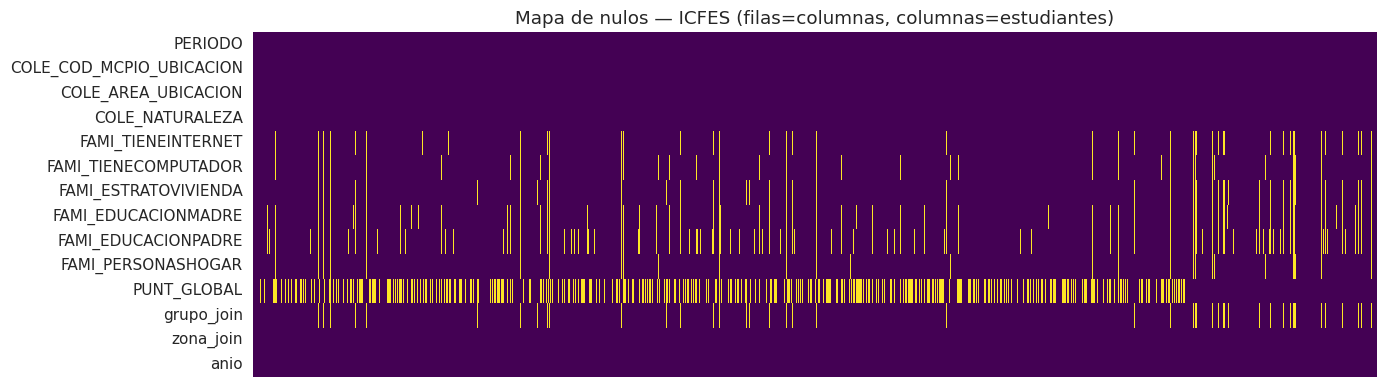

In [19]:
# Celda 1.5 — Revisión de nulos
nulos = df_icfes_enc.isnull().sum()
pct   = (nulos / len(df_icfes_enc) * 100).round(2)
resumen = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct})
print(resumen[resumen['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False))

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(df_icfes_enc.isnull().T, cbar=False, xticklabels=False,
            ax=ax, cmap='viridis')
ax.set_title('Mapa de nulos — ICFES (filas=columnas, columnas=estudiantes)')
plt.tight_layout()
plt.show()

In [14]:
df_icfes_enc.head(4)

,PERIODO,COLE_COD_MCPIO_UBICACION,COLE_AREA_UBICACION,COLE_NATURALEZA,FAMI_TIENEINTERNET,FAMI_TIENECOMPUTADOR,FAMI_ESTRATOVIVIENDA,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_PERSONASHOGAR,PUNT_GLOBAL,grupo_join,zona_join,anio
0,20162,15759,1,0,1.0000,1.0000,2.0000,4.0000,4.0000,2.0000,287.0000,B,1,2016
1,20102,41551,1,0,0.0000,0.0000,1.0000,3.0000,1.0000,5.0000,NaN,A,1,2010
2,20112,41551,1,0,1.0000,1.0000,1.0000,3.0000,1.0000,4.0000,NaN,A,1,2011
3,20162,41551,0,0,0.0000,1.0000,1.0000,1.0000,1.0000,3.0000,167.0000,A,2,2016


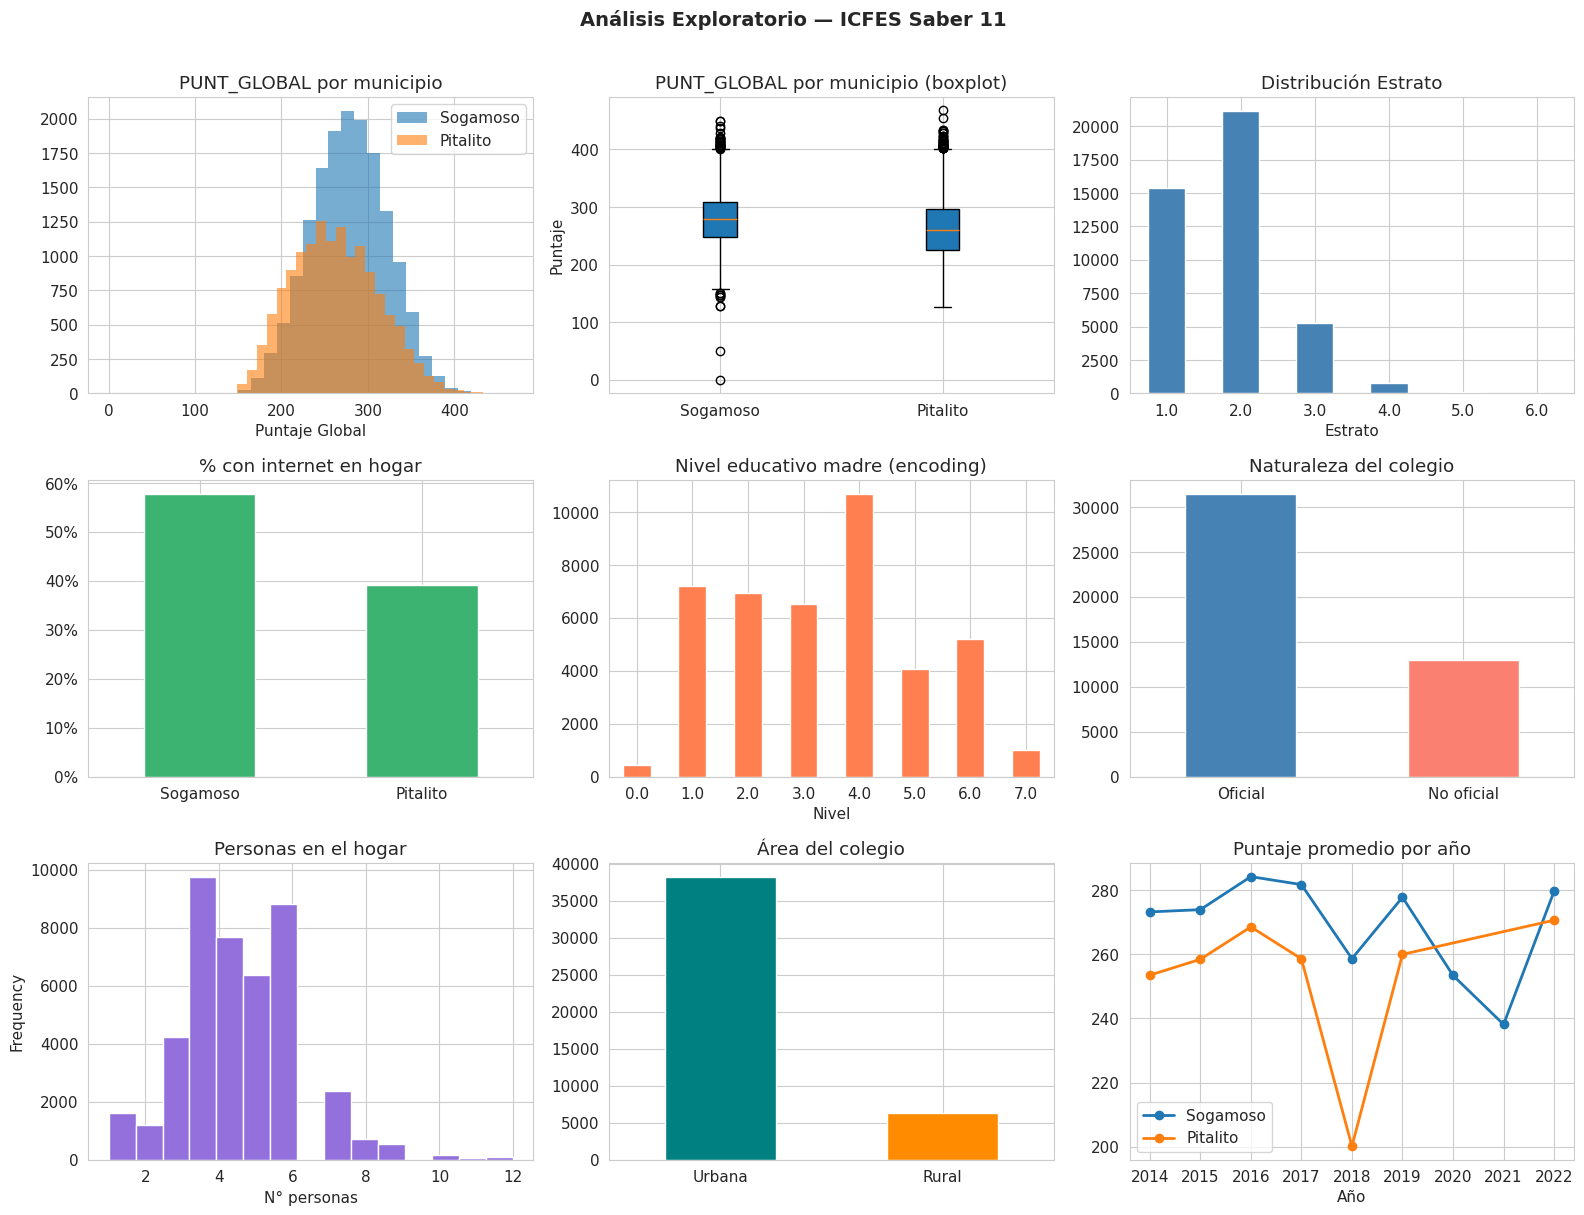


─── Estadísticos descriptivos ───


,PERIODO,COLE_COD_MCPIO_UBICACION,COLE_AREA_UBICACION,COLE_NATURALEZA,FAMI_TIENEINTERNET,FAMI_TIENECOMPUTADOR,FAMI_ESTRATOVIVIENDA,FAMI_EDUCACIONMADRE,FAMI_EDUCACIONPADRE,FAMI_PERSONASHOGAR,PUNT_GLOBAL,zona_join,anio
count,44398.0000,44398.0000,44398.0000,44398.0000,43176.0000,43218.0000,42794.0000,42080.0000,40668.0000,43627.0000,29878.0000,44398.0000,44398.0000
mean,20161.5693,27816.7222,0.8594,0.2915,0.4905,0.5741,1.8132,3.3751,3.1132,4.4821,270.7412,1.1406,2015.8915
std,39.4776,12868.8708,0.3476,0.4545,0.4999,0.4945,0.7518,1.7138,1.7779,1.5731,47.4280,0.3476,3.8668
min,20101.0000,15759.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,2010.0000
25%,20132.0000,15759.0000,1.0000,0.0000,0.0000,0.0000,1.0000,2.0000,2.0000,3.5000,237.0000,1.0000,2013.0000
50%,20162.0000,15759.0000,1.0000,0.0000,0.0000,1.0000,2.0000,3.0000,3.0000,4.0000,271.0000,1.0000,2016.0000
75%,20194.0000,41551.0000,1.0000,1.0000,1.0000,1.0000,2.0000,4.0000,4.0000,5.5000,304.0000,1.0000,2019.0000
max,20224.0000,41551.0000,1.0000,1.0000,1.0000,1.0000,6.0000,7.0000,7.0000,12.0000,468.0000,2.0000,2022.0000


In [20]:
# Celda 1.6 — Distribuciones del ICFES
fig = plt.figure(figsize=(16, 12))

# Histograma PUNT_GLOBAL por municipio
ax1 = fig.add_subplot(3, 3, 1)
for m in MUNICIPIOS:
    d = df_icfes_enc[df_icfes_enc['COLE_COD_MCPIO_UBICACION'] == m]['PUNT_GLOBAL'].dropna()
    ax1.hist(d, bins=30, alpha=0.6, label=NOMBRE_MUN[m], edgecolor='none')
ax1.set_title('PUNT_GLOBAL por municipio')
ax1.set_xlabel('Puntaje Global')
ax1.legend()

# Boxplot PUNT_GLOBAL por municipio
ax2 = fig.add_subplot(3, 3, 2)
data_box = [df_icfes_enc[df_icfes_enc['COLE_COD_MCPIO_UBICACION'] == m]['PUNT_GLOBAL'].dropna()
            for m in MUNICIPIOS]
ax2.boxplot(data_box, labels=[NOMBRE_MUN[m] for m in MUNICIPIOS], patch_artist=True)
ax2.set_title('PUNT_GLOBAL por municipio (boxplot)')
ax2.set_ylabel('Puntaje')

# Distribución estrato
ax3 = fig.add_subplot(3, 3, 3)
df_icfes_enc['FAMI_ESTRATOVIVIENDA'].value_counts().sort_index().plot(
    kind='bar', ax=ax3, color='steelblue', edgecolor='white')
ax3.set_title('Distribución Estrato')
ax3.set_xlabel('Estrato')
ax3.tick_params(axis='x', rotation=0)

# % con internet por municipio
ax4 = fig.add_subplot(3, 3, 4)
inet = df_icfes_enc.groupby('COLE_COD_MCPIO_UBICACION')['FAMI_TIENEINTERNET'].mean()
inet.index = [NOMBRE_MUN[m] for m in inet.index]
inet.plot(kind='bar', ax=ax4, color='mediumseagreen', edgecolor='white')
ax4.set_title('% con internet en hogar')
ax4.tick_params(axis='x', rotation=0)
ax4.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

# Educación madre
ax5 = fig.add_subplot(3, 3, 5)
df_icfes_enc['FAMI_EDUCACIONMADRE'].value_counts().sort_index().plot(
    kind='bar', ax=ax5, color='coral', edgecolor='white')
ax5.set_title('Nivel educativo madre (encoding)')
ax5.set_xlabel('Nivel')
ax5.tick_params(axis='x', rotation=0)

# Naturaleza colegio
ax6 = fig.add_subplot(3, 3, 6)
nat = df_icfes_enc['COLE_NATURALEZA'].value_counts()
nat.index = ['Oficial' if i == 0 else 'No oficial' for i in nat.index]
nat.plot(kind='bar', ax=ax6, color=['steelblue', 'salmon'], edgecolor='white')
ax6.set_title('Naturaleza del colegio')
ax6.tick_params(axis='x', rotation=0)

# Personas en el hogar
ax7 = fig.add_subplot(3, 3, 7)
df_icfes_enc['FAMI_PERSONASHOGAR'].dropna().plot(
    kind='hist', bins=15, ax=ax7, color='mediumpurple', edgecolor='white')
ax7.set_title('Personas en el hogar')
ax7.set_xlabel('N° personas')

# Área urbano/rural
ax8 = fig.add_subplot(3, 3, 8)
area = df_icfes_enc['COLE_AREA_UBICACION'].value_counts()
area.index = ['Urbana' if i == 1 else 'Rural' for i in area.index]
area.plot(kind='bar', ax=ax8, color=['teal', 'darkorange'], edgecolor='white')
ax8.set_title('Área del colegio')
ax8.tick_params(axis='x', rotation=0)

# Evolución temporal del puntaje promedio
ax9 = fig.add_subplot(3, 3, 9)
for m in MUNICIPIOS:
    df_m = df_icfes_enc[df_icfes_enc['COLE_COD_MCPIO_UBICACION'] == m]
    prom = df_m.groupby('anio')['PUNT_GLOBAL'].mean()
    ax9.plot(prom.index, prom.values, marker='o', label=NOMBRE_MUN[m], linewidth=2)
ax9.set_title('Puntaje promedio por año')
ax9.set_xlabel('Año')
ax9.legend()

plt.suptitle('Análisis Exploratorio — ICFES Saber 11', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n─── Estadísticos descriptivos ───")
display(df_icfes_enc.describe())



In [22]:
# Celda 1.7 -- Limpieza, filtro temporal y columna SPLIT
df_icfes_clean = df_icfes_enc.copy()

# ── 0. Eliminar registros con PUNT_GLOBAL nulo PRIMERO ──────────────
# Hacerlo antes de cualquier imputacion o winsorización:
# no tiene sentido estimar percentiles ni imputar variables en filas sin target
print("--- Eliminacion de PUNT_GLOBAL nulo ---")
n_antes_punt = len(df_icfes_clean)
df_icfes_clean = df_icfes_clean[df_icfes_clean["PUNT_GLOBAL"].notna()].copy()
n_drop = n_antes_punt - len(df_icfes_clean)
print(f"  Eliminados  : {n_drop:,}  ({n_drop / n_antes_punt * 100:.2f}% del total)")
print(f"  Conservados : {len(df_icfes_clean):,}")

# ── 1. Imputacion de nulos ───────────────────────────────────────────
print("\n--- Imputacion de nulos ---")

# a) TIENEINTERNET y TIENECOMPUTADOR: mediana POR ANO
#    La conectividad mejora ano a ano; usar mediana global subestimaría
#    la conectividad de los anos recientes y la sobreestimaría en los anteriores.
for col in ["FAMI_TIENEINTERNET", "FAMI_TIENECOMPUTADOR"]:
    n = df_icfes_clean[col].isnull().sum()
    df_icfes_clean[col] = (
        df_icfes_clean
        .groupby("anio")[col]
        .transform(lambda x: x.fillna(x.median()))
    )
    # Fallback global para anios con solo nulos
    saldo = df_icfes_clean[col].isnull().sum()
    if saldo > 0:
        df_icfes_clean[col] = df_icfes_clean[col].fillna(df_icfes_clean[col].median())
        print(f"  {col}: {n:,} nulos -> mediana por anio  (+ {saldo} fallback global)")
    else:
        print(f"  {col}: {n:,} nulos -> mediana por anio")

# b) Resto de FAMI numericas: mediana global
for col in ["FAMI_EDUCACIONMADRE", "FAMI_EDUCACIONPADRE", "FAMI_PERSONASHOGAR"]:
    n   = df_icfes_clean[col].isnull().sum()
    med = df_icfes_clean[col].median()
    df_icfes_clean[col] = df_icfes_clean[col].fillna(med)
    print(f"  {col}: {n:,} nulos -> mediana ({med:.2f})")

# c) FAMI_ESTRATOVIVIENDA: mediana global -> luego recalcular grupo_join
#    grupo_join NO se imputa por moda independientemente;
#    se deriva del estrato imputado para garantizar coherencia entre ambas columnas
col_est = "FAMI_ESTRATOVIVIENDA"
n_est   = df_icfes_clean[col_est].isnull().sum()
med_est = df_icfes_clean[col_est].median()
df_icfes_clean[col_est] = df_icfes_clean[col_est].fillna(med_est)
print(f"  {col_est}: {n_est:,} nulos -> mediana ({med_est:.2f})")

ESTRATO_NUM_A_GRUPO = {1: "A", 2: "B", 3: "C", 4: "C", 5: "D", 6: "D"}
df_icfes_clean["grupo_join"] = (
    df_icfes_clean[col_est]
    .round().astype(int)
    .map(ESTRATO_NUM_A_GRUPO)
)
n_gj_nulo = df_icfes_clean["grupo_join"].isnull().sum()
print(f"  grupo_join: recalculado desde {col_est} imputado  "
      f"(nulos restantes tras mapeo: {n_gj_nulo})")

# d) Columnas institucionales: moda
for col in ["COLE_NATURALEZA", "COLE_AREA_UBICACION"]:
    n    = df_icfes_clean[col].isnull().sum()
    moda = df_icfes_clean[col].mode()[0]
    df_icfes_clean[col] = df_icfes_clean[col].fillna(moda)
    print(f"  {col}: {n:,} nulos -> moda ({moda})")

# e) zona_join: moda (derivada de COLE_AREA_UBICACION, ya imputada arriba)
n_zona    = df_icfes_clean["zona_join"].isnull().sum()
moda_zona = df_icfes_clean["zona_join"].mode()[0]
df_icfes_clean["zona_join"] = df_icfes_clean["zona_join"].fillna(moda_zona)
print(f"  zona_join: {n_zona:,} nulos -> moda ({moda_zona})")

# ── 2. Winsorización PUNT_GLOBAL ─────────────────────────────────────
# (hacerla aqui, con el dataset ya limpio de nulos en PUNT_GLOBAL)
p1  = df_icfes_clean["PUNT_GLOBAL"].quantile(0.01)
p99 = df_icfes_clean["PUNT_GLOBAL"].quantile(0.99)
df_icfes_clean["PUNT_GLOBAL"] = df_icfes_clean["PUNT_GLOBAL"].clip(p1, p99)
print(f"\n  PUNT_GLOBAL winsorizado: [{p1:.1f}, {p99:.1f}]")

# ── 3. Filtro temporal ───────────────────────────────────────────────
# Anos conservados: 2015-2017 (historico limpio), 2019 (pre-pandemia), 2022 (test)
# Descartados: 2010-2014 (muy lejanos al corte SISBEN 2022)
#              2018 (33 registros -- incompleto)
#              2020-2021 (5 y 8 registros -- incompleto, pandemia)
ANIOS_VALIDOS = [2015, 2016, 2017, 2019, 2022]

antes = len(df_icfes_clean)
df_icfes_clean = df_icfes_clean[df_icfes_clean["anio"].isin(ANIOS_VALIDOS)].copy()

print(f"\n--- Filtro temporal ---")
print(f"  Anos conservados : {ANIOS_VALIDOS}")
print(f"  Registros antes  : {antes:,}  ->  despues: {len(df_icfes_clean):,}"
      f"  (descartados: {antes - len(df_icfes_clean):,})")
print("\n  Registros por ano:")
print(df_icfes_clean["anio"].value_counts().sort_index().to_frame("Estudiantes"))

# ── 4. Columna SPLIT ─────────────────────────────────────────────────
# test  -> 2022 (reservado, no tocar hasta seccion 6)
# train -> 2015, 2016, 2017, 2019
df_icfes_clean["SPLIT"] = df_icfes_clean["anio"].apply(
    lambda a: "test" if a == 2022 else "train"
)
print("\n--- Distribucion del split temporal ---")
split_resumen = (
    df_icfes_clean
    .groupby(["SPLIT", "anio"])
    .size()
    .to_frame("Estudiantes")
)
print(split_resumen.to_string())
print(f"\n  Train (2015/16/17/19): {(df_icfes_clean['SPLIT']=='train').sum():,}")
print(f"  Test  (2022)         : {(df_icfes_clean['SPLIT']=='test').sum():,}")

print(f"\ndf_icfes_clean shape final: {df_icfes_clean.shape}")


--- Eliminacion de PUNT_GLOBAL nulo ---
  Eliminados  : 14,520  (32.70% del total)
  Conservados : 29,878

--- Imputacion de nulos ---
  FAMI_TIENEINTERNET: 1,047 nulos -> mediana por anio
  FAMI_TIENECOMPUTADOR: 595 nulos -> mediana por anio
  FAMI_EDUCACIONMADRE: 1,448 nulos -> mediana (4.00)
  FAMI_EDUCACIONPADRE: 2,540 nulos -> mediana (3.00)
  FAMI_PERSONASHOGAR: 596 nulos -> mediana (4.00)
  FAMI_ESTRATOVIVIENDA: 1,388 nulos -> mediana (2.00)
  grupo_join: recalculado desde FAMI_ESTRATOVIVIENDA imputado  (nulos restantes tras mapeo: 0)
  COLE_NATURALEZA: 0 nulos -> moda (0)
  COLE_AREA_UBICACION: 0 nulos -> moda (1)
  zona_join: 0 nulos -> moda (1)

  PUNT_GLOBAL winsorizado: [171.0, 378.0]

--- Filtro temporal ---
  Anos conservados : [2015, 2016, 2017, 2019, 2022]
  Registros antes  : 29,878  ->  despues: 26,183  (descartados: 3,695)

  Registros por ano:
      Estudiantes
anio             
2015         3843
2016         3570
2017         3803
2019         7558
2022         740

Empty DataFrame
Columns: [Nulos, Porcentaje (%)]
Index: []


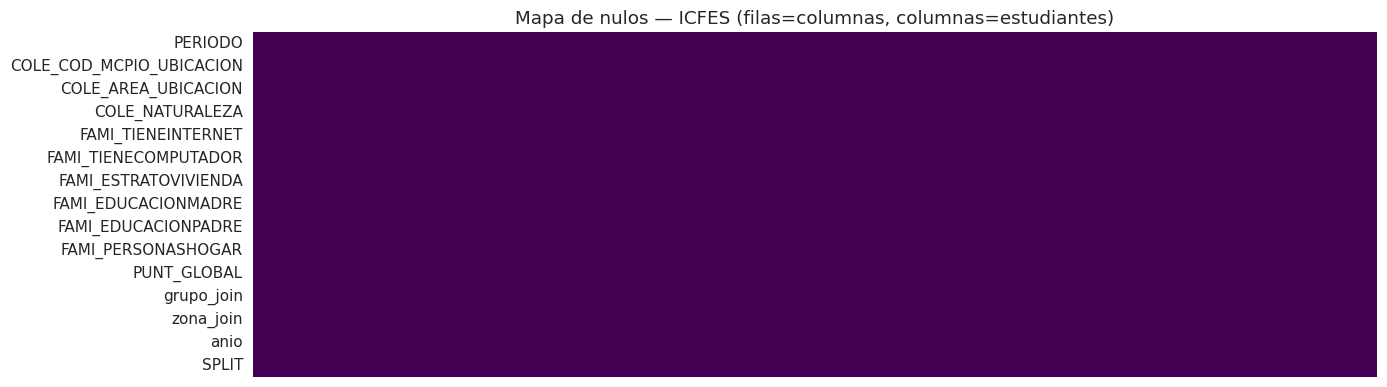

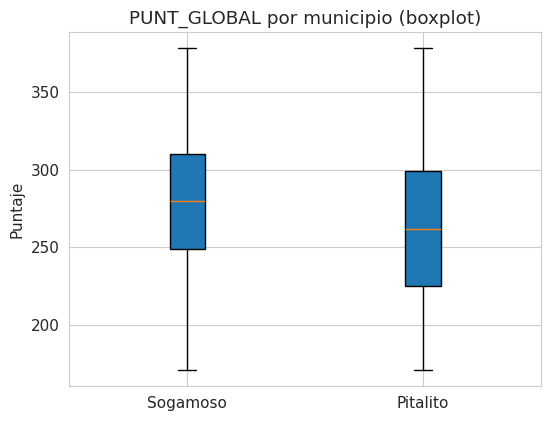

In [23]:
# Celda 1.5 — Revisión de nulos
nulos = df_icfes_clean.isnull().sum()
pct   = (nulos / len(df_icfes_enc) * 100).round(2)
resumen = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct})
print(resumen[resumen['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False))

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(df_icfes_clean.isnull().T, cbar=False, xticklabels=False,
            ax=ax, cmap='viridis')
ax.set_title('Mapa de nulos — ICFES (filas=columnas, columnas=estudiantes)')
plt.tight_layout()
plt.show()

# Boxplot PUNT_GLOBAL por municipio
fig = plt.figure(figsize=(16, 12))
ax2 = fig.add_subplot(3, 3, 2)
data_box = [df_icfes_clean[df_icfes_clean['COLE_COD_MCPIO_UBICACION'] == m]['PUNT_GLOBAL'].dropna()
            for m in MUNICIPIOS]
ax2.boxplot(data_box, labels=[NOMBRE_MUN[m] for m in MUNICIPIOS], patch_artist=True)
ax2.set_title('PUNT_GLOBAL por municipio (boxplot)')
ax2.set_ylabel('Puntaje')

plt.tight_layout()
plt.show()

---
## SECCIÓN 2 — Dataset SISBEN

In [24]:
# Celda 2.1 — Carga del dataframe SISBEN
df_sisben_raw = pd.read_csv(SISBEN_FILE, low_memory=False)

print(f"Shape original: {df_sisben_raw.shape}")
print(f"\nDistribución por municipio (antes del filtro):")
print(df_sisben_raw['cod_mpio'].value_counts().rename(NOMBRE_MUN).to_frame('Registros'))

# ── Filtro de edad: per002 == 3 → grupo 12-17 años ───────────────────
df_sisben_raw = df_sisben_raw[df_sisben_raw['PER002'] == 3].copy()

print(f"\nShape tras filtro per002==3 (12-17 años): {df_sisben_raw.shape}")
print(f"\nDistribución por municipio (después del filtro):")
print(df_sisben_raw['cod_mpio'].value_counts().rename(NOMBRE_MUN).to_frame('Registros'))

display(df_sisben_raw.head(3))
df_sisben_raw.info()

Shape original: (9042, 48)

Distribución por municipio (antes del filtro):
          Registros
cod_mpio           
Pitalito       5283
Sogamoso       3759

Shape tras filtro per002==3 (12-17 años): (913, 48)

Distribución por municipio (después del filtro):
          Registros
cod_mpio           
Pitalito        527
Sogamoso        386


,cod_mpio,H_5,I1,I2,I3,I4,I5,I6,I7,I8,I9,I10,I11,I12,I13,I14,I15,Grupo,Nivel,Clasificacion,ZONA,llave,CORTE,HOGAR,ORDEN,FEX,PER001,PER002,PER003,PER004,PER005,PER005B,PER006,PER006B,PER007,PER008,PER009,PER010,PER011,PER012,PER013,PER014,PER015,PER016,PER017,PER018,PER019,PER020
7,41551,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,C,9,C9,1,673,SIV_2022,1,2,"19,905608755",2,3,3,2,9,99,1,1,1,2,9,9,2,2,9,9,1,1,2,2,4,99
8,15759,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,A,3,A3,2,647,SIV_2022,1,4,"5,7913769124",2,3,3,2,9,99,1,1,3,2,9,9,2,2,9,9,1,1,2,9,4,99
19,41551,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,C,2,C2,1,649,SIV_2022,1,3,"19,905608755",1,3,3,2,9,99,1,1,1,2,9,9,9,9,9,9,1,1,2,2,4,99


<class 'pandas.core.frame.DataFrame'>
Index: 913 entries, 7 to 9038
Data columns (total 48 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   cod_mpio       913 non-null    int64 
 1   H_5            913 non-null    int64 
 2   I1             913 non-null    int64 
 3   I2             913 non-null    int64 
 4   I3             913 non-null    int64 
 5   I4             913 non-null    int64 
 6   I5             913 non-null    int64 
 7   I6             913 non-null    int64 
 8   I7             913 non-null    int64 
 9   I8             913 non-null    int64 
 10  I9             913 non-null    int64 
 11  I10            913 non-null    int64 
 12  I11            913 non-null    int64 
 13  I12            913 non-null    int64 
 14  I13            913 non-null    int64 
 15  I14            913 non-null    int64 
 16  I15            913 non-null    int64 
 17  Grupo          913 non-null    object
 18  Nivel          913 non-null    int

In [25]:
# Celda 2.2 — Selección de columnas a usar
COLS_SISBEN = [
    'cod_mpio',       # llave municipio
    'H_5',            # IPM compuesto (proxy pobreza multidimensional) — feature
    'I1',             # Privación: bajo logro educativo — feature
    'I2',             # Privación: analfabetismo — feature
    'I3',             # Privación: inasistencia escolar — feature
    'I4',             # Privación: rezago escolar — feature
    'I6',             # Privación: trabajo infantil — feature
    'I15',            # Privación: hacinamiento — feature
    'Nivel',          # Nivel SISBEN numérico — feature
    'Grupo',          # Grupo SISBEN (A/B/C/D) — llave de join con ICFES
    'ZONA',           # 1=Cabecera/Urbana, 2=Resto/Rural — llave de join
    'PER001',         # Sexo — feature control
    'PER015',         # Sabe leer y escribir — feature
    'PER017',         # Nivel educativo — feature
]

df_sisben = df_sisben_raw[COLS_SISBEN].copy()
print(f"Columnas seleccionadas: {df_sisben.shape[1]}")
print(f"Filas: {df_sisben.shape[0]:,}")
print(f"\nGrupos SISBEN disponibles: {sorted(df_sisben['Grupo'].dropna().unique())}")
df_sisben.head(3)

Columnas seleccionadas: 14
Filas: 913

Grupos SISBEN disponibles: ['A', 'B', 'C', 'D']


,cod_mpio,H_5,I1,I2,I3,I4,I6,I15,Nivel,Grupo,ZONA,PER001,PER015,PER017
7,41551,0,0,0,0,0,0,0,9,C,1,2,1,2
8,15759,0,0,0,0,0,0,0,3,A,2,2,1,2
19,41551,0,1,0,0,1,0,0,2,C,1,1,1,2


In [26]:
# Celda 2.3 — Tipos de datos e inspección de valores clave para el join
print("─── Tipos de datos ───")
print(df_sisben.dtypes)

print("\n─── ZONA (crítico para el join) ───")
print(df_sisben['ZONA'].value_counts().to_frame('Registros'))
print("→ 1 = Cabecera municipal (Urbano) | 2 = Resto (Rural)")

print("\n─── Clasificacion SISBEN ───")
print(df_sisben['Grupo'].value_counts().sort_index().to_frame('Registros'))

print("\n─── Nivel SISBEN ───")
print(df_sisben['Nivel'].value_counts().sort_index().head(10))

─── Tipos de datos ───
cod_mpio     int64
H_5          int64
I1           int64
I2           int64
I3           int64
I4           int64
I6           int64
I15          int64
Nivel        int64
Grupo       object
ZONA         int64
PER001       int64
PER015       int64
PER017       int64
dtype: object

─── ZONA (crítico para el join) ───
      Registros
ZONA           
2           465
1           448
→ 1 = Cabecera municipal (Urbano) | 2 = Resto (Rural)

─── Clasificacion SISBEN ───
       Registros
Grupo           
A            157
B            492
C            243
D             21

─── Nivel SISBEN ───
Nivel
1     118
2     146
3     139
4     128
5     153
6      76
7      76
8      10
9      13
10     12
Name: count, dtype: int64


In [27]:
# Celda 2.4 — Renombrado y conversión a numéricos
df_sisben_enc = df_sisben.copy()

# Renombrar a minúsculas para consistencia
df_sisben_enc = df_sisben_enc.rename(columns={
    'H_5': 'h5', 'I1': 'i1', 'I2': 'i2', 'I3': 'i3',
    'I4': 'i4', 'I6': 'i6', 'I15': 'i15',
    'Nivel': 'nivel', 'Grupo': 'grupo', 'ZONA': 'zona',
    'PER001': 'per001', 'PER015': 'per015', 'PER017': 'per017'
})

# Convertir a numérico
cols_num = ['h5', 'i1', 'i2', 'i3', 'i4', 'i6', 'i15', 'nivel', 'per001', 'per015', 'per017']
for col in cols_num:
    df_sisben_enc[col] = pd.to_numeric(df_sisben_enc[col], errors='coerce')

# Valores 9 y 99 = 'No aplica / Sin información' en SISBEN → NaN
for col in ['per015', 'per017']:
    df_sisben_enc[col] = df_sisben_enc[col].replace([9, 99], np.nan)

print("  Tipos de datos SISBEN tras conversión:")
print(df_sisben_enc.dtypes)
print(f"\nGrupos únicos (llave de join): {sorted(df_sisben_enc['grupo'].dropna().unique())}")
print(f"Zonas únicas: {sorted(df_sisben_enc['zona'].dropna().unique())} → 1=Urbana, 2=Rural")

  Tipos de datos SISBEN tras conversión:
cod_mpio     int64
h5           int64
i1           int64
i2           int64
i3           int64
i4           int64
i6           int64
i15          int64
nivel        int64
grupo       object
zona         int64
per001       int64
per015       int64
per017       int64
dtype: object

Grupos únicos (llave de join): ['A', 'B', 'C', 'D']
Zonas únicas: [np.int64(1), np.int64(2)] → 1=Urbana, 2=Rural


In [28]:
# Celda 2.5 — Revisión de nulos SISBEN
nulos_s = df_sisben_enc.isnull().sum()
pct_s   = (nulos_s / len(df_sisben_enc) * 100).round(2)
resumen_s = pd.DataFrame({'Nulos': nulos_s, 'Porcentaje (%)': pct_s})
print(resumen_s[resumen_s['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False))

Empty DataFrame
Columns: [Nulos, Porcentaje (%)]
Index: []


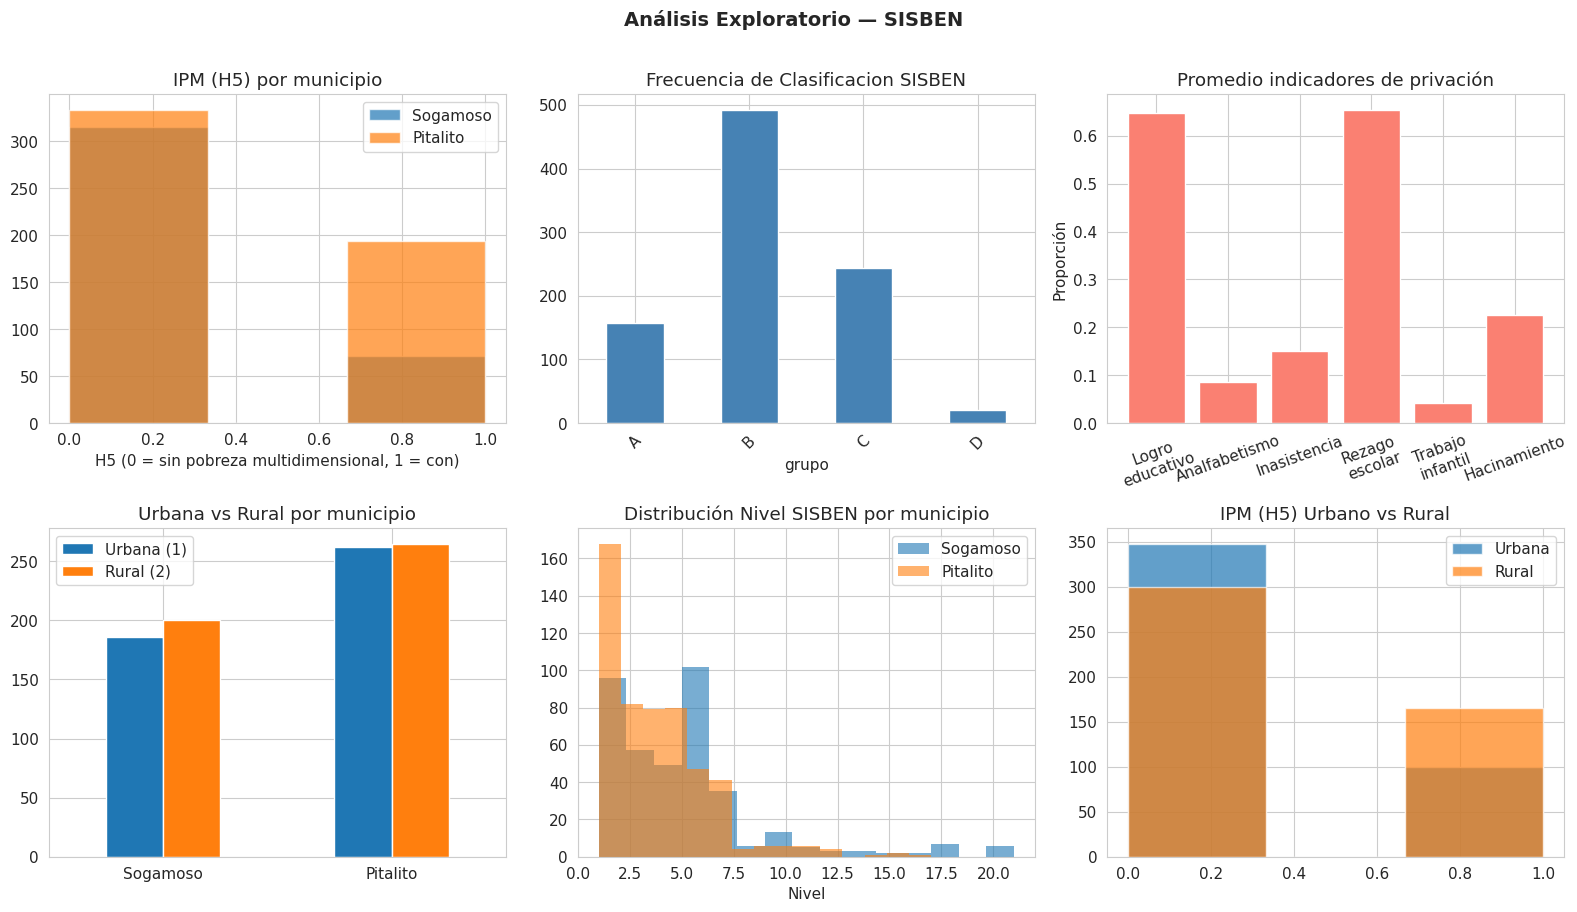

In [29]:
# Celda 2.6 — Distribuciones del SISBEN
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# IPM (h5) por municipio
for m in MUNICIPIOS:
    d = df_sisben_enc[df_sisben_enc['cod_mpio'] == m]['h5']
    axes[0,0].hist(d, bins=3, alpha=0.7, label=NOMBRE_MUN[m], edgecolor='white')
axes[0,0].set_title('IPM (H5) por municipio')
axes[0,0].legend()
axes[0,0].set_xlabel('H5 (0 = sin pobreza multidimensional, 1 = con)')

# Clasificacion SISBEN
df_sisben_enc['grupo'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0,1], color='steelblue', edgecolor='white')
axes[0,1].set_title('Frecuencia de Clasificacion SISBEN')
axes[0,1].tick_params(axis='x', rotation=45)

# Indicadores de privación (promedio)
indicadores = ['i1','i2','i3','i4','i6','i15']
labels_ind  = ['Logro\neducativo','Analfabetismo','Inasistencia',
               'Rezago\nescolar','Trabajo\ninfantil','Hacinamiento']
promedios   = df_sisben_enc[indicadores].mean()
axes[0,2].bar(labels_ind, promedios, color='salmon', edgecolor='white')
axes[0,2].set_title('Promedio indicadores de privación')
axes[0,2].set_ylabel('Proporción')
axes[0,2].tick_params(axis='x', rotation=20)

# Zona por municipio
zona_cnt = df_sisben_enc.groupby(['cod_mpio','zona']).size().unstack(fill_value=0)
zona_cnt.index = [NOMBRE_MUN[m] for m in zona_cnt.index]
zona_cnt.columns = ['Urbana (1)', 'Rural (2)']
zona_cnt.plot(kind='bar', ax=axes[1,0], edgecolor='white')
axes[1,0].set_title('Urbana vs Rural por municipio')
axes[1,0].tick_params(axis='x', rotation=0)
axes[1,0].legend()

# Nivel SISBEN por municipio
for m in MUNICIPIOS:
    d = df_sisben_enc[df_sisben_enc['cod_mpio'] == m]['nivel'].dropna()
    axes[1,1].hist(d, bins=15, alpha=0.6, label=NOMBRE_MUN[m], edgecolor='none')
axes[1,1].set_title('Distribución Nivel SISBEN por municipio')
axes[1,1].set_xlabel('Nivel')
axes[1,1].legend()

# IPM Urbano vs Rural
for zona, nombre in [(1,'Urbana'), (2,'Rural')]:
    d = df_sisben_enc[df_sisben_enc['zona'] == zona]['h5']
    axes[1,2].hist(d, bins=3, alpha=0.7, label=nombre, edgecolor='white')
axes[1,2].set_title('IPM (H5) Urbano vs Rural')
axes[1,2].legend()

plt.suptitle('Análisis Exploratorio — SISBEN', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
# Celda 2.7 — Limpieza y agregación final del SISBEN
df_sisben_clean = df_sisben_enc.copy()

# Imputar nulos con mediana
for col in ['h5', 'i1', 'i2', 'i3', 'i4', 'i6', 'i15', 'nivel']:
    n = df_sisben_clean[col].isnull().sum()
    if n > 0:
        med = df_sisben_clean[col].median()
        df_sisben_clean[col] = df_sisben_clean[col].fillna(med)
        print(f"  {col}: {n} nulos → mediana ({med:.4f})")

# Agregación por municipio + zona + grupo (A/B/C/D)
# Cada fila = perfil SISBEN promedio de ese segmento socioeconómico
# Máximo 16 grupos: 2 municipios × 2 zonas × 4 letras → match rate ~100%
df_sisben_agg = (
    df_sisben_clean
    .groupby(['cod_mpio', 'zona', 'grupo'])
    .agg(
        h5_prom    =('h5',    'mean'),
        i1_prom    =('i1',    'mean'),
        i2_prom    =('i2',    'mean'),
        i3_prom    =('i3',    'mean'),
        i4_prom    =('i4',    'mean'),
        i6_prom    =('i6',    'mean'),
        i15_prom   =('i15',   'mean'),
        nivel_prom =('nivel', 'mean'),
        n_sisben   =('h5',    'count')
    )
    .reset_index()
)

print(f"\ndf_sisben_agg shape: {df_sisben_agg.shape}")
print(f"Grupos únicos en el agregado: {len(df_sisben_agg)}")
print()
display(df_sisben_agg)


df_sisben_agg shape: (16, 12)
Grupos únicos en el agregado: 16



,cod_mpio,zona,grupo,h5_prom,i1_prom,i2_prom,i3_prom,i4_prom,i6_prom,i15_prom,nivel_prom,n_sisben
0,15759,1,A,0.0714,0.5000,0.0000,0.0714,0.5714,0.0000,0.5714,3.9286,14
1,15759,1,B,0.2125,0.5125,0.0375,0.1000,0.5875,0.0250,0.3500,3.9875,80
2,15759,1,C,0.0897,0.2949,0.0256,0.1282,0.6026,0.0256,0.1795,5.9872,78
3,15759,1,D,0.0000,0.0000,0.0000,0.1429,0.2143,0.0000,0.0000,16.3571,14
4,15759,2,A,0.4286,0.7959,0.1224,0.0816,0.5714,0.0000,0.4490,3.7551,49
5,15759,2,B,0.1714,0.6952,0.0476,0.0476,0.5905,0.0000,0.2000,4.0667,105
6,15759,2,C,0.1591,0.6591,0.0000,0.1136,0.5455,0.0682,0.0455,5.0909,44
7,15759,2,D,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,3.5000,2
8,41551,1,A,0.5490,0.7255,0.2157,0.2157,0.9804,0.0196,0.5294,3.7059,51
9,41551,1,B,0.2910,0.6791,0.0672,0.1194,0.7463,0.0448,0.2687,3.6642,134


---
## SECCIÓN 3 — Dataset MEN

In [31]:
# Celda 3.1 — Carga del dataframe MEN
df_men_raw = pd.read_csv(MEN_FILE)

print(f"Shape original: {df_men_raw.shape}")
print(f"Años disponibles: {sorted(df_men_raw['AÑO'].unique())}")

# ── Filtro: conservar solo los años del ICFES ────────────────────────
# ANIOS_VALIDOS = [2015, 2016, 2017, 2019, 2022] — definido en celda 1.7
df_men_raw = df_men_raw[df_men_raw['AÑO'].isin(ANIOS_VALIDOS)].copy()

print(f"\nShape tras filtro {ANIOS_VALIDOS}: {df_men_raw.shape}")
print(f"Municipios: {sorted(df_men_raw['CÓDIGO_MUNICIPIO'].unique())}")
print(f"Años conservados: {sorted(df_men_raw['AÑO'].unique())}")

df_men_raw.head()

Shape original: (28, 41)
Años disponibles: [np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Shape tras filtro [2015, 2016, 2017, 2019, 2022]: (10, 41)
Municipios: [np.int64(15759), np.int64(41551)]
Años conservados: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2019), np.int64(2022)]


,AÑO,CÓDIGO_MUNICIPIO,MUNICIPIO,CÓDIGO_DEPARTAMENTO,DEPARTAMENTO,CÓDIGO_ETC,ETC,POBLACIÓN_5_16,TASA_MATRICULACIÓN_5_16,COBERTURA_NETA,COBERTURA_NETA_TRANSICIÓN,COBERTURA_NETA_PRIMARIA,COBERTURA_NETA_SECUNDARIA,COBERTURA_NETA_MEDIA,COBERTURA_BRUTA,COBERTURA_BRUTA_TRANSICIÓN,COBERTURA_BRUTA_PRIMARIA,COBERTURA_BRUTA_SECUNDARIA,COBERTURA_BRUTA_MEDIA,TAMAÑO_PROMEDIO_DE_GRUPO,SEDES_CONECTADAS_A_INTERNET,DESERCIÓN,DESERCIÓN_TRANSICIÓN,DESERCIÓN_PRIMARIA,DESERCIÓN_SECUNDARIA,DESERCIÓN_MEDIA,APROBACIÓN,APROBACIÓN_TRANSICIÓN,APROBACIÓN_PRIMARIA,APROBACIÓN_SECUNDARIA,APROBACIÓN_MEDIA,REPROBACIÓN,REPROBACIÓN_TRANSICIÓN,REPROBACIÓN_PRIMARIA,REPROBACIÓN_SECUNDARIA,REPROBACIÓN_MEDIA,REPITENCIA,REPITENCIA_TRANSICIÓN,REPITENCIA_PRIMARIA,REPITENCIA_SECUNDARIA,REPITENCIA_MEDIA
4,2022,15759,Sogamoso,15,Boyacá,3772.0000,Sogamoso,22917.0000,"112,34%","112,17%","82,88%",104%,"106,16%","73,47%","123,26%","111,26%","115,68%","134,7%","123,55%",NaN,NaN,"2,39%","2,69%","1,59%","3,32%","2,01%","89,73%","0,07%","93,92%","83,46%","91,19%","7,87%","0,07%","4,49%","13,23%","6,8%","6,14%","2,4%","5,42%","8,86%","2,89%"
5,2022,41551,Pitalito,41,Huila,4436.0000,Pitalito,28926.0000,"99,48%","99,46%","79,99%","101,95%","81,34%","45,11%","112,34%","112,26%","118,61%","115,43%","90,74%",NaN,NaN,"4,67%","3,74%","3,26%","6,96%","4,42%","83,62%","0,26%","89,36%","73,25%","81,07%","11,71%","0,26%","7,38%","19,79%","14,51%","7,33%","0,04%","7,2%","10,3%","4,31%"
10,2019,41551,Pitalito,41,Huila,4436.0000,Pitalito,28317.0000,"103,29%","103,26%","76,46%","101,13%","88,07%","44,5%","117,47%","111,73%","119,95%","128,81%","91,8%",NaN,NaN,"4,95%","4,63%","2,99%","7,79%","4,17%","83,39%","0,13%","89,03%","72,89%","84,93%","11,66%","0,13%","7,97%","19,32%","10,9%","5,13%","0,36%","3,59%","8,36%","4,67%"
11,2019,15759,Sogamoso,15,Boyacá,3772.0000,Sogamoso,22803.0000,"114,13%","113,9%","71,91%","107,94%","105,84%","68,82%","129,75%","104,09%","123,61%","146,14%","123,54%",NaN,NaN,"1,79%","2,29%","1,41%","2,26%","1,42%","93,07%","0,63%","95,65%","88,84%","95,08%","5,14%","0,63%","2,94%","8,9%","3,51%","2,19%","0,55%","1,13%","3,82%","1,63%"
14,2017,15759,Sogamoso,15,Boyacá,3772.0000,Sogamoso,22331.0000,"114,4%","114,25%","76,36%","111,51%","101,74%","67,94%","129,9%","110,14%","127,69%","140,38%","122,48%","30,296%",100%,"1,43%","2,41%","1,18%","1,69%","0,99%","95,89%",0%,"96,89%","94,36%","96,29%","2,68%",0%,"1,93%","3,95%","2,72%","2,63%","0,66%","2,02%","4,3%","0,88%"


In [32]:
# Celda 3.2 — Selección y renombrado de columnas MEN
COLS_MEN = [
    'AÑO',
    'CÓDIGO_MUNICIPIO',
    'COBERTURA_NETA_MEDIA',
    'DESERCIÓN_MEDIA',
    'APROBACIÓN_MEDIA',
]
df_men = df_men_raw[COLS_MEN].copy()
df_men = df_men.rename(columns={
    'AÑO':                  'anio',
    'CÓDIGO_MUNICIPIO':     'cod_municipio',
    'COBERTURA_NETA_MEDIA': 'cobertura_neta_media',
    'DESERCIÓN_MEDIA':      'desercion_media',
    'APROBACIÓN_MEDIA':     'aprobacion_media',
})
print(f"Columnas: {df_men.columns.tolist()}")
df_men.head()

Columnas: ['anio', 'cod_municipio', 'cobertura_neta_media', 'desercion_media', 'aprobacion_media']


,anio,cod_municipio,cobertura_neta_media,desercion_media,aprobacion_media
4,2022,15759,"73,47%","2,01%","91,19%"
5,2022,41551,"45,11%","4,42%","81,07%"
10,2019,41551,"44,5%","4,17%","84,93%"
11,2019,15759,"68,82%","1,42%","95,08%"
14,2017,15759,"67,94%","0,99%","96,29%"


In [33]:
# Celda 3.3 — Tipos de datos (identificar strings con %)
print(df_men.dtypes)
print("\nEjemplos de valores (notar coma decimal y símbolo %):")
for col in ['cobertura_neta_media', 'desercion_media', 'aprobacion_media']:
    print(f"  {col}: '{df_men[col].iloc[0]}'")

anio                     int64
cod_municipio            int64
cobertura_neta_media    object
desercion_media         object
aprobacion_media        object
dtype: object

Ejemplos de valores (notar coma decimal y símbolo %):
  cobertura_neta_media: '73,47%'
  desercion_media: '2,01%'
  aprobacion_media: '91,19%'


In [34]:
# Celda 3.4 — Transformación: limpiar "%" y convertir a float [0,1]
def pct_a_float(serie):
    return (
        serie.astype(str)
             .str.replace('%', '', regex=False)
             .str.replace(',', '.', regex=False)
             .str.strip()
             .replace('nan', np.nan)
             .pipe(pd.to_numeric, errors='coerce')
             .div(100)
    )

pct_cols = ['cobertura_neta_media', 'desercion_media', 'aprobacion_media']
for col in pct_cols:
    df_men[col] = pct_a_float(df_men[col])

print("  Tipos tras conversión:")
print(df_men.dtypes)
print()
df_men.describe()

  Tipos tras conversión:
anio                      int64
cod_municipio             int64
cobertura_neta_media    float64
desercion_media         float64
aprobacion_media        float64
dtype: object



,anio,cod_municipio,cobertura_neta_media,desercion_media,aprobacion_media
count,10.0000,10.0000,10.0000,10.0000,10.0000
mean,2017.8000,28655.0000,0.5592,0.0317,0.8892
std,2.6162,13593.5776,0.1348,0.0170,0.0651
min,2015.0000,15759.0000,0.4093,0.0099,0.8107
25%,2016.0000,15759.0000,0.4374,0.0181,0.8289
50%,2017.0000,28655.0000,0.5506,0.0309,0.8806
75%,2019.0000,41551.0000,0.6779,0.0458,0.9557
max,2022.0000,41551.0000,0.7347,0.0524,0.9629


In [35]:
# Celda 3.5 — Revisión de nulos MEN
nulos_m = df_men.isnull().sum()
pct_m   = (nulos_m / len(df_men) * 100).round(2)
print(pd.DataFrame({'Nulos': nulos_m, 'Porcentaje (%)': pct_m}))

                      Nulos  Porcentaje (%)
anio                      0          0.0000
cod_municipio             0          0.0000
cobertura_neta_media      0          0.0000
desercion_media           0          0.0000
aprobacion_media          0          0.0000


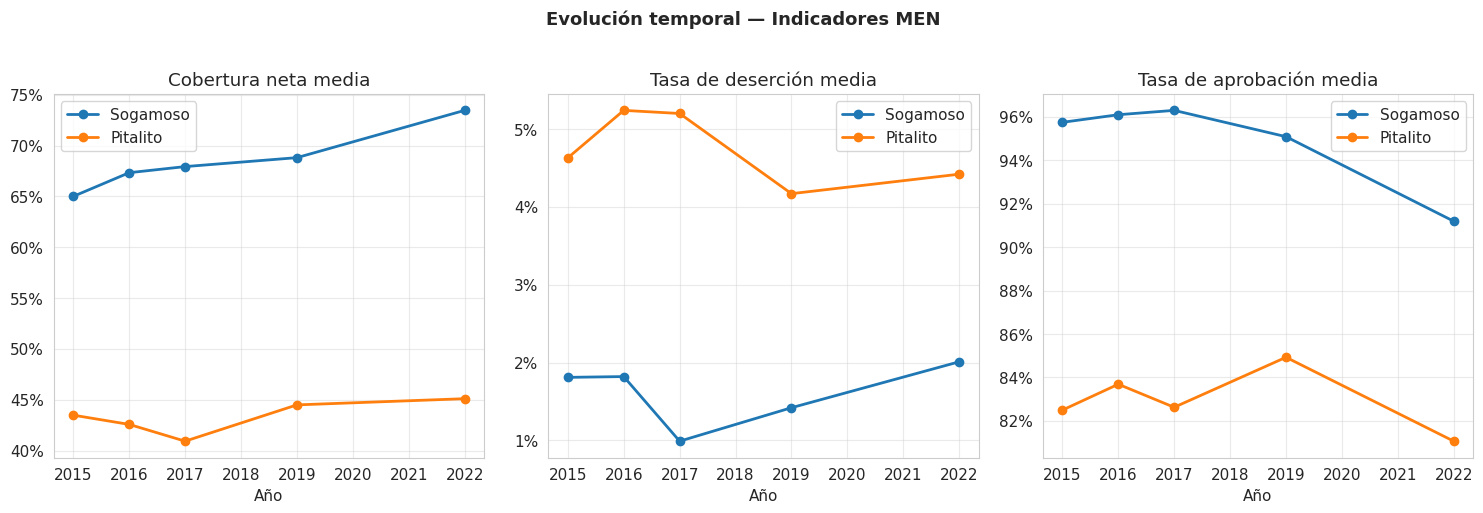


─── Promedio por municipio ───


,cobertura_neta_media,desercion_media,aprobacion_media
cod_municipio,,,
Sogamoso,0.6852,0.0161,0.9488
Pitalito,0.4332,0.0473,0.8296


In [36]:
# Celda 3.6 — Evolución temporal de variables MEN
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

variables = ['cobertura_neta_media', 'desercion_media', 'aprobacion_media']
titulos   = ['Cobertura neta media', 'Tasa de deserción media', 'Tasa de aprobación media']

for ax, var, titulo in zip(axes, variables, titulos):
    for m in MUNICIPIOS:
        dm = df_men[df_men['cod_municipio'] == m].sort_values('anio')
        ax.plot(dm['anio'], dm[var], marker='o', label=NOMBRE_MUN[m], linewidth=2)
    ax.set_title(titulo)
    ax.set_xlabel('Año')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.legend()
    ax.grid(True, alpha=0.4)

plt.suptitle('Evolución temporal — Indicadores MEN', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n─── Promedio por municipio ───")
display(df_men.groupby('cod_municipio')[variables].mean().rename(index=NOMBRE_MUN))

In [37]:
# Celda 3.7 — Limpieza y preparación final del MEN
df_men_clean = df_men.copy()

pct_cols = ['cobertura_neta_media', 'desercion_media', 'aprobacion_media']

# Interpolación lineal temporal por municipio
for m in MUNICIPIOS:
    mask = df_men_clean['cod_municipio'] == m
    for col in pct_cols:
        n = df_men_clean.loc[mask, col].isnull().sum()
        if n > 0:
            vals = (df_men_clean.loc[mask]
                    .sort_values('anio')[col]
                    .interpolate(method='linear').values)
            df_men_clean.loc[mask, col] = vals
            print(f"  {NOMBRE_MUN[m]} | {col}: {n} nulo(s) → interpolado")

for col in pct_cols:
    if df_men_clean[col].isnull().any():
        df_men_clean[col] = df_men_clean[col].fillna(df_men_clean[col].median())

print(f"df_men_clean shape: {df_men_clean.shape}")
print(f"Nulos restantes: {df_men_clean.isnull().sum().sum()}")
df_men_clean.head()

df_men_clean shape: (10, 5)
Nulos restantes: 0


,anio,cod_municipio,cobertura_neta_media,desercion_media,aprobacion_media
4,2022,15759,0.7347,0.0201,0.9119
5,2022,41551,0.4511,0.0442,0.8107
10,2019,41551,0.4450,0.0417,0.8493
11,2019,15759,0.6882,0.0142,0.9508
14,2017,15759,0.6794,0.0099,0.9629


---
## SECCIÓN 4 — Joins y construcción del dataset final

--- Cortes de terciles (P33 / P66) ---
  Clase 0 (Bajo  (<P33)): [171.0 -- 250.0]
  Clase 1 (Medio (P33-P66)): [250.0 -- 294.0]
  Clase 2 (Alto  (>P66)): [294.0 -- 378.0]

--- Distribucion de clases (~33% cada una) ---
  Clase 0 (Bajo  ): 8,841  (33.8%)  ################
  Clase 1 (Medio ): 8,748  (33.4%)  ################
  Clase 2 (Alto  ): 8,594  (32.8%)  ################


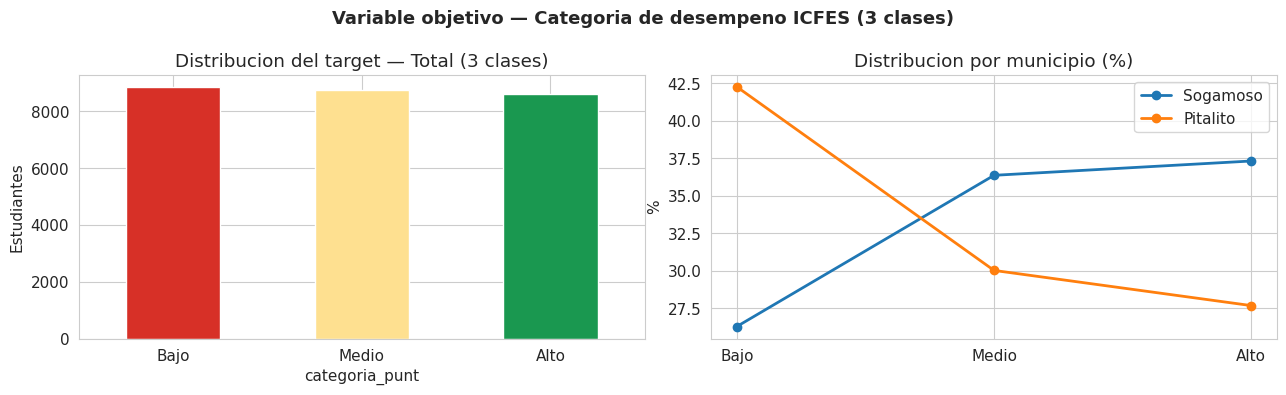

In [38]:
# Celda 4.1 -- Construccion del target (TERCILES de PUNT_GLOBAL)
# 3 clases: Bajo (<P33), Medio (P33-P66), Alto (>P66)
# Clases balanceadas ~33% cada una (mejor separacion para clasificacion)
df_con_target = df_icfes_clean.copy()

# Terciles sobre datos reales combinados de Sogamoso + Pitalito
df_con_target['categoria_punt'], bins = pd.qcut(
    df_con_target['PUNT_GLOBAL'],
    q=3,
    labels=[0, 1, 2],
    retbins=True,
    duplicates='drop'
)
df_con_target['categoria_punt'] = df_con_target['categoria_punt'].astype(int)

print("--- Cortes de terciles (P33 / P66) ---")
etiquetas_corte = ["Bajo  (<P33)", "Medio (P33-P66)", "Alto  (>P66)"]
for i, (lo, hi) in enumerate(zip(bins[:-1], bins[1:])):
    print(f"  Clase {i} ({etiquetas_corte[i]}): [{lo:.1f} -- {hi:.1f}]")

print("\n--- Distribucion de clases (~33% cada una) ---")
dist = df_con_target['categoria_punt'].value_counts().sort_index()
for cls, cnt in dist.items():
    pct = cnt / len(df_con_target) * 100
    bar = '#' * int(pct / 2)
    print(f"  Clase {cls} ({CLASES_TARGET[cls]:6s}): {cnt:5,}  ({pct:.1f}%)  {bar}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
dist.plot(kind='bar', ax=axes[0], color=['#d73027','#fee090','#1a9850'], edgecolor='white')
axes[0].set_xticklabels([CLASES_TARGET[i] for i in dist.index], rotation=0)
axes[0].set_title('Distribucion del target — Total (3 clases)')
axes[0].set_ylabel('Estudiantes')

for m in MUNICIPIOS:
    df_m = df_con_target[df_con_target['COLE_COD_MCPIO_UBICACION'] == m]
    pct_m = df_m['categoria_punt'].value_counts(normalize=True).sort_index() * 100
    axes[1].plot(pct_m.index, pct_m.values, marker='o', label=NOMBRE_MUN[m], linewidth=2)
axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels([CLASES_TARGET[i] for i in range(3)], rotation=0)
axes[1].set_title('Distribucion por municipio (%)')
axes[1].set_ylabel('%')
axes[1].legend()

plt.suptitle('Variable objetivo — Categoria de desempeno ICFES (3 clases)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [39]:
# Celda 4.2 — Join ICFES + SISBEN
# Join por municipio + zona + grupo (A/B/C/D)
# Estrato ICFES se mapeó a grupo SISBEN en celda 1.4:
#   Estrato 1→A, 2→B, 3→C, 4→C, 5→D, 6→D
# Match rate esperado ~100% (solo falla si estrato era NaN y grupo_join fue imputado)

df_join1 = df_con_target.merge(
    df_sisben_agg,
    left_on =['COLE_COD_MCPIO_UBICACION', 'zona_join', 'grupo_join'],
    right_on=['cod_mpio',                 'zona',      'grupo'],
    how='left'
)

print(f"Shape tras join ICFES + SISBEN: {df_join1.shape}")

cols_sisben_res = ['h5_prom','i1_prom','i2_prom','i3_prom',
                   'i4_prom','i6_prom','i15_prom','nivel_prom']
match_pct = df_join1['h5_prom'].notna().mean() * 100
print(f"Match rate con SISBEN: {match_pct:.1f}%  ")
print(f"\nNulos por feature SISBEN:")
print(df_join1[cols_sisben_res].isnull().sum().to_frame('Nulos'))

Shape tras join ICFES + SISBEN: (26183, 28)
Match rate con SISBEN: 100.0%  

Nulos por feature SISBEN:
            Nulos
h5_prom         0
i1_prom         0
i2_prom         0
i3_prom         0
i4_prom         0
i6_prom         0
i15_prom        0
nivel_prom      0


In [40]:
# Celda 4.3 — Join resultado + MEN (por municipio + año)
df_final = df_join1.merge(
    df_men_clean,
    left_on =['COLE_COD_MCPIO_UBICACION', 'anio'],
    right_on=['cod_municipio', 'anio'],
    how='left'
)

print(f"Shape final: {df_final.shape}")

cols_men_res = ['cobertura_neta_media', 'desercion_media', 'aprobacion_media']
match_men = df_final['cobertura_neta_media'].notna().mean() * 100
print(f"Match rate con MEN: {match_men:.1f}%")
print(f"\nNulos por feature MEN tras join:")
print(df_final[cols_men_res].isnull().sum().to_frame('Nulos'))

Shape final: (26183, 32)
Match rate con MEN: 100.0%

Nulos por feature MEN tras join:
                      Nulos
cobertura_neta_media      0
desercion_media           0
aprobacion_media          0


In [41]:
# Celda 4.4 — Revisión del dataset final + imputación final
print(f"Shape: {df_final.shape}")
nulos_f = df_final.isnull().sum()
print(f"\nColumnas con nulos:")
print(nulos_f[nulos_f > 0].sort_values(ascending=False))

# Imputación final con mediana (features SISBEN y MEN sin match)
cols_imp = cols_sisben_res + cols_men_res
for col in cols_imp:
    n = df_final[col].isnull().sum()
    if n > 0:
        med = df_final[col].median()
        df_final[col] = df_final[col].fillna(med)
        print(f"  {col}: {n:,} nulos → mediana ({med:.4f})")

print(f"\nNulos restantes: {df_final.isnull().sum().sum()}")

print("\n─── Distribución target por municipio ───────────────────────────")
tabla = (df_final
         .groupby(['COLE_COD_MCPIO_UBICACION', 'categoria_punt'])
         .size()
         .unstack()
         .rename(index=NOMBRE_MUN, columns=CLASES_TARGET))
display(tabla)

Shape: (26183, 32)

Columnas con nulos:
Series([], dtype: int64)

Nulos restantes: 0

─── Distribución target por municipio ───────────────────────────


categoria_punt,Bajo,Medio,Alto
COLE_COD_MCPIO_UBICACION,,,
Sogamoso,3666,5071,5204
Pitalito,5175,3677,3390


---
## SECCIÓN 5 — Preparación para modelos

Features candidatos: 20


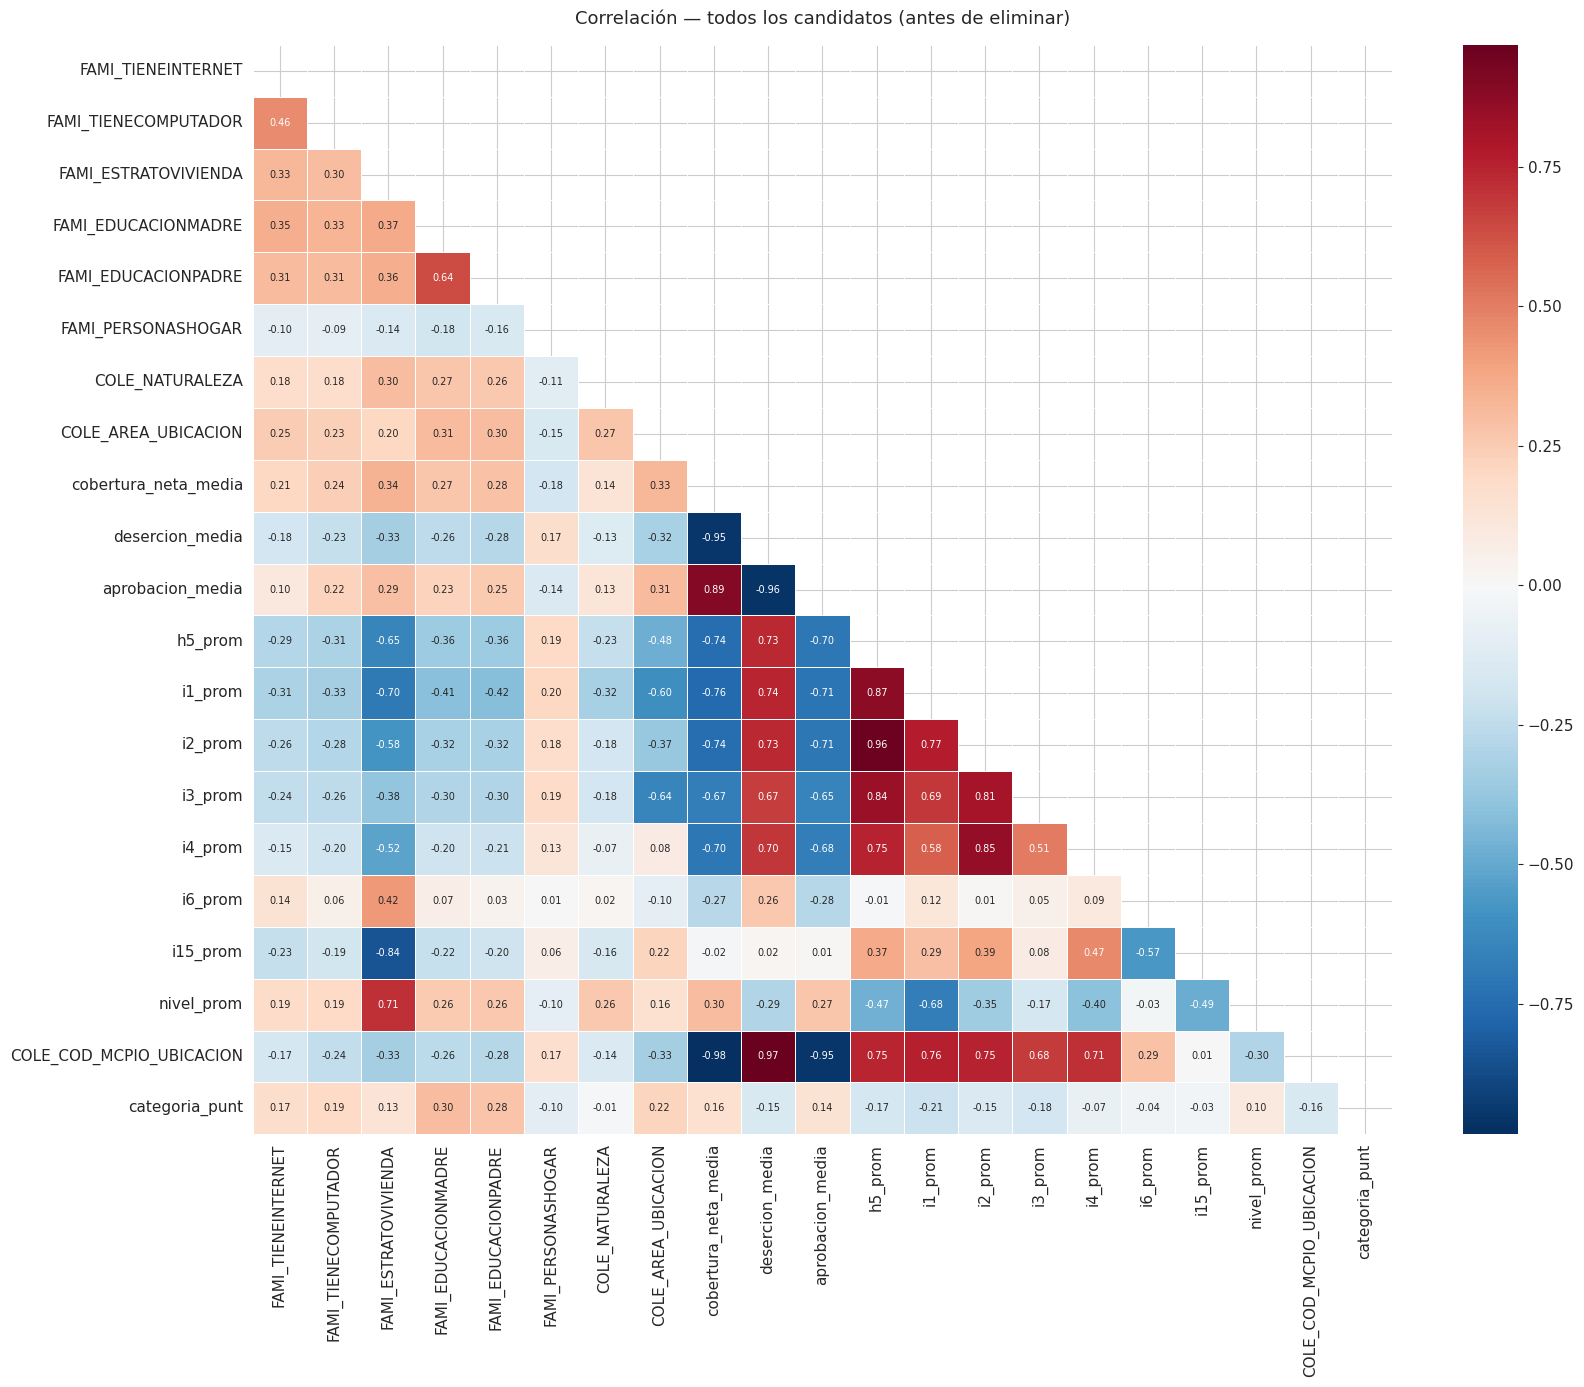

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

─── Features eliminadas ─────────────────────────────────────────
  ✗  cobertura_neta_media         r > 0.95 con COLE_COD_MCPIO_UBICACION — redundante con municipio
  ✗  desercion_media              r > 0.95 con COLE_COD_MCPIO_UBICACION — redundante con municipio
  ✗  aprobacion_media             r > 0.95 con COLE_COD_MCPIO_UBICACION — redundante con municipio
  ✗  i2_prom                      r = 0.958 con h5_prom — el IPM ya resume esta privación
  ✗  i6_prom                      r < 0.05 con target — sin poder predictivo
  ✗  i15_prom                     r < 0.05 con target — sin poder predictivo
  ✗  COLE_NATURALEZA              r < 0.05 con target — sin poder predictivo
  ✗  FAMI_PERSONASHOGAR           sesgo de cardinalidad Gini: alta granularidad infla importancia artificial

─── Features finales del modelo (12) ──────────────────────
  ✓  FAMI_TIENEINTERNET
  ✓  FAMI_TIENECOMPUTADOR
  ✓  FAMI_ESTRATOVIVIENDA
  ✓  FAMI_EDUCACIONMADRE
  ✓  FAMI_EDUCACIONPADRE
  ✓  COLE_AREA_UBICA

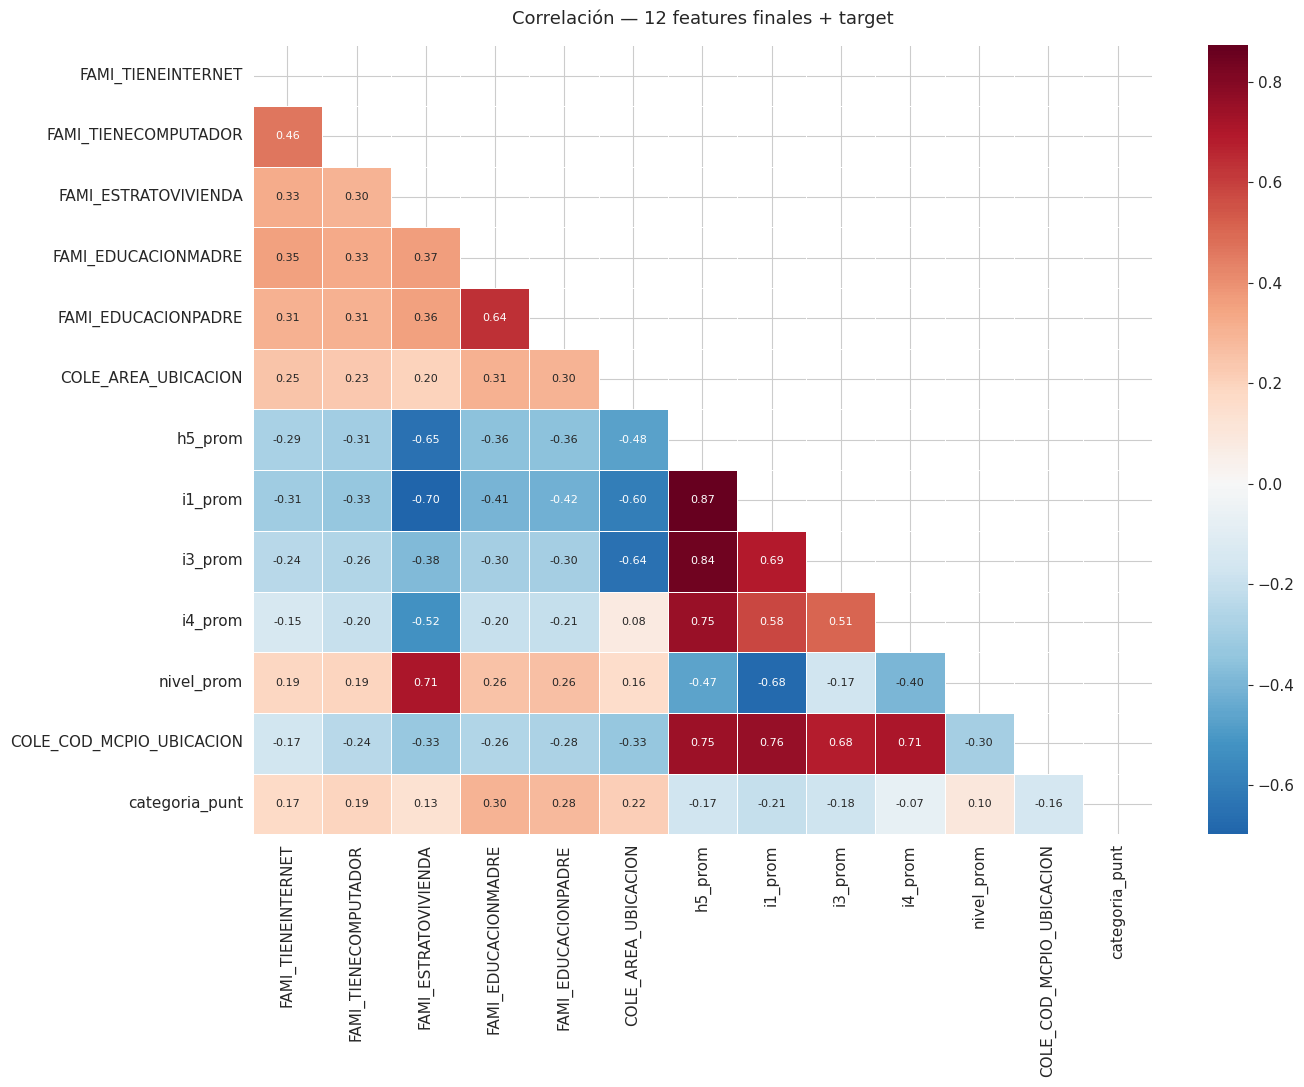

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


─── Correlación de cada feature con el target ───────────────────


,r con categoria_punt
FAMI_EDUCACIONMADRE,0.3040
FAMI_EDUCACIONPADRE,0.2809
COLE_AREA_UBICACION,0.2157
i1_prom,-0.2128
FAMI_TIENECOMPUTADOR,0.1924
i3_prom,-0.1779
h5_prom,-0.1710
FAMI_TIENEINTERNET,0.1692
COLE_COD_MCPIO_UBICACION,-0.1566
FAMI_ESTRATOVIVIENDA,0.1328


In [55]:
# Celda 5.1 — Correlación y eliminación de features por multicolinealidad
from google.colab import files
TARGET_COL = 'categoria_punt'

# ── 1. Features candidatos (antes de eliminar) ────────────────────────
FEATURES_HOGAR  = ['FAMI_TIENEINTERNET', 'FAMI_TIENECOMPUTADOR', 'FAMI_ESTRATOVIVIENDA',
                   'FAMI_EDUCACIONMADRE', 'FAMI_EDUCACIONPADRE', 'FAMI_PERSONASHOGAR']
FEATURES_INST   = ['COLE_NATURALEZA', 'COLE_AREA_UBICACION']
FEATURES_MEN    = ['cobertura_neta_media', 'desercion_media', 'aprobacion_media']
FEATURES_SISBEN = ['h5_prom', 'i1_prom', 'i2_prom', 'i3_prom',
                   'i4_prom', 'i6_prom', 'i15_prom', 'nivel_prom']
FEATURE_CTRL    = ['COLE_COD_MCPIO_UBICACION']

CANDIDATOS = FEATURES_HOGAR + FEATURES_INST + FEATURES_MEN + FEATURES_SISBEN + FEATURE_CTRL
print(f"Features candidatos: {len(CANDIDATOS)}")

# ── 2. Heatmap con todos los candidatos (para ver qué eliminar) ───────
corr_full = df_final[CANDIDATOS + [TARGET_COL]].corr()

fig, ax = plt.subplots(figsize=(17, 14))
mask = np.triu(np.ones_like(corr_full, dtype=bool))
sns.heatmap(corr_full, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 7})
ax.set_title('Correlación — todos los candidatos (antes de eliminar)', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('heatmap_candidatos.png', dpi=150, bbox_inches='tight')
plt.show()
files.download('heatmap_candidatos.png')

# ── 3. Eliminación documentada ────────────────────────────────────────
FEATURES_ELIMINAR = {
    'cobertura_neta_media': 'r > 0.95 con COLE_COD_MCPIO_UBICACION — redundante con municipio',
    'desercion_media'     : 'r > 0.95 con COLE_COD_MCPIO_UBICACION — redundante con municipio',
    'aprobacion_media'    : 'r > 0.95 con COLE_COD_MCPIO_UBICACION — redundante con municipio',
    'i2_prom'             : 'r = 0.958 con h5_prom — el IPM ya resume esta privación',
    'i6_prom'             : 'r < 0.05 con target — sin poder predictivo',
    'i15_prom'            : 'r < 0.05 con target — sin poder predictivo',
    'COLE_NATURALEZA'     : 'r < 0.05 con target — sin poder predictivo',
    'FAMI_PERSONASHOGAR'  : 'sesgo de cardinalidad Gini: alta granularidad infla importancia artificial',
}

print("─── Features eliminadas ─────────────────────────────────────────")
for feat, razon in FEATURES_ELIMINAR.items():
    print(f"  ✗  {feat:28s} {razon}")

# ── 4. ALL_FEATURES finales ───────────────────────────────────────────
ALL_FEATURES = [f for f in CANDIDATOS if f not in FEATURES_ELIMINAR]

print(f"\n─── Features finales del modelo ({len(ALL_FEATURES)}) ──────────────────────")
for f in ALL_FEATURES:
    print(f"  ✓  {f}")

# ── 5. Shape del dataset resultante ──────────────────────────────────
print(f"\nShape dataset con features finales: {df_final[ALL_FEATURES].shape}")

# ── 6. Verificar que no quedan pares con |r| > 0.85 ──────────────────
print("\n─── Verificación: pares con |r| > 0.85 (entre features) ─────────")
corr_final = df_final[ALL_FEATURES + [TARGET_COL]].corr()
found = False
for i in range(len(ALL_FEATURES)):
    for j in range(i + 1, len(ALL_FEATURES)):
        val = corr_final.iloc[i, j]
        if abs(val) > 0.85:
            print(f"   {ALL_FEATURES[i]}  ↔  {ALL_FEATURES[j]}:  {val:.3f}")
            found = True
if not found:
    print("   Ningún par con |r| > 0.85 — multicolinealidad resuelta")

# ── 7. Heatmap final (features seleccionadas) ─────────────────────────
fig, ax = plt.subplots(figsize=(14, 11))
mask2 = np.triu(np.ones_like(corr_final, dtype=bool))
sns.heatmap(corr_final, mask=mask2, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 8})
ax.set_title(f'Correlación — {len(ALL_FEATURES)} features finales + target', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('heatmap_features_finales.png', dpi=150, bbox_inches='tight')
plt.show()
files.download('heatmap_features_finales.png')
print("\n─── Correlación de cada feature con el target ───────────────────")
corr_target = corr_final[TARGET_COL].drop(TARGET_COL).sort_values(key=abs, ascending=False)
display(corr_target.to_frame('r con categoria_punt'))

In [43]:
# Celda 5.2 — Normalización con StandardScaler
# Fit SOLO en train para evitar data leakage del test (2022)

df_model = df_final[ALL_FEATURES + [TARGET_COL, 'SPLIT']].copy()

# Features continuas/ordinales a escalar (excluir binarias 0/1 y control municipio)
# Nota: las 8 features eliminadas en 5.1 ya no estan en ALL_FEATURES
# FAMI_PERSONASHOGAR eliminada por sesgo de cardinalidad Gini
FEATURES_ESCALAR = ['FAMI_ESTRATOVIVIENDA', 'FAMI_EDUCACIONMADRE', 'FAMI_EDUCACIONPADRE',
                    'h5_prom', 'i1_prom', 'i3_prom', 'i4_prom', 'nivel_prom']

mask_train = df_model['SPLIT'] == 'train'
mask_test  = df_model['SPLIT'] == 'test'

scaler = StandardScaler()
df_model_scaled = df_model.copy()

df_model_scaled.loc[mask_train, FEATURES_ESCALAR] = scaler.fit_transform(
    df_model.loc[mask_train, FEATURES_ESCALAR])
df_model_scaled.loc[mask_test,  FEATURES_ESCALAR] = scaler.transform(
    df_model.loc[mask_test,  FEATURES_ESCALAR])

print(f"  StandardScaler ajustado en train ({mask_train.sum():,} filas), "
      f"aplicado a test ({mask_test.sum():,} filas)")
print(f"   Features escaladas: {len(FEATURES_ESCALAR)}  |  "

      f"Features binarias sin escalar: {len(ALL_FEATURES) - len(FEATURES_ESCALAR)}")
print("\nEstadísticos post-escala en TRAIN (media ≈ 0, std ≈ 1):")
display(df_model_scaled.loc[mask_train, FEATURES_ESCALAR].describe().T[['mean','std']].round(4))

  StandardScaler ajustado en train (18,774 filas), aplicado a test (7,409 filas)
   Features escaladas: 8  |  Features binarias sin escalar: 4

Estadísticos post-escala en TRAIN (media ≈ 0, std ≈ 1):


,mean,std
FAMI_ESTRATOVIVIENDA,0.0000,1.0000
FAMI_EDUCACIONMADRE,0.0000,1.0000
FAMI_EDUCACIONPADRE,0.0000,1.0000
h5_prom,0.0000,1.0000
i1_prom,-0.0000,1.0000
i3_prom,-0.0000,1.0000
i4_prom,-0.0000,1.0000
nivel_prom,0.0000,1.0000


In [45]:
# Celda 5.3 — Split temporal Train / Test
# Train: 2015, 2016, 2017, 2019  |  Test: 2022 (reservado — solo se usa en sección 6)

mask_train = df_model_scaled['SPLIT'] == 'train'
mask_test  = df_model_scaled['SPLIT'] == 'test'

X_train = df_model_scaled.loc[mask_train, ALL_FEATURES]
y_train = df_model_scaled.loc[mask_train, TARGET_COL]
X_test  = df_model_scaled.loc[mask_test,  ALL_FEATURES]
y_test  = df_model_scaled.loc[mask_test,  TARGET_COL]

print(f"Dataset total          : {len(df_model_scaled):,} estudiantes  |  {len(ALL_FEATURES)} features")
print(f"Train (2015/16/17/19)  : {len(X_train):,} ({len(X_train)/len(df_model_scaled)*100:.0f}%)")
print(f"Test  (2022)           : {len(X_test):,} ({len(X_test)/len(df_model_scaled)*100:.0f}%)")

print("\n─── Distribución de clases en Train ─────────────────────────────")
for cls in sorted(y_train.unique()):
    n   = (y_train == cls).sum()
    pct = n / len(y_train) * 100
    print(f"  Clase {cls} ({CLASES_TARGET[cls]:9s}): {n:5,}  ({pct:.1f}%)")

print("\n─── Distribución de clases en Test ──────────────────────────────")
for cls in sorted(y_test.unique()):
    n   = (y_test == cls).sum()
    pct = n / len(y_test) * 100
    print(f"  Clase {cls} ({CLASES_TARGET[cls]:9s}): {n:5,}  ({pct:.1f}%)")

print("\n X_train, X_test, y_train, y_test listos.")
print("    X_test / y_test reservados — no usar hasta la Sección 6.")

Dataset total          : 26,183 estudiantes  |  12 features
Train (2015/16/17/19)  : 18,774 (72%)
Test  (2022)           : 7,409 (28%)

─── Distribución de clases en Train ─────────────────────────────
  Clase 0 (Bajo     ): 6,528  (34.8%)
  Clase 1 (Medio    ): 6,367  (33.9%)
  Clase 2 (Alto     ): 5,879  (31.3%)

─── Distribución de clases en Test ──────────────────────────────
  Clase 0 (Bajo     ): 2,313  (31.2%)
  Clase 1 (Medio    ): 2,381  (32.1%)
  Clase 2 (Alto     ): 2,715  (36.6%)

 X_train, X_test, y_train, y_test listos.
    X_test / y_test reservados — no usar hasta la Sección 6.


In [46]:
# Celda 5.4 -- Feature Engineering (variables derivadas)
# Las nuevas variables capturan interacciones entre features existentes
# que los modelos no pueden explotar nativamente evaluando cada
# variable por separado.

# VARIABLE 1: capital_educativo
# Suma el nivel educativo codificado de ambos padres.
# Rango posible: 0 (ambos sin educacion) a 14 (ambos con posgrado).
# Captura el capital educativo acumulado del hogar como unidad,
# no solo de cada padre por separado. Un hogar con ambos padres
# universitarios tiene una ventaja compuesta mayor que la suma
# individual: el ambiente de estudio, el vocabulario, las
# expectativas y el apoyo academico son cualitativamente diferentes.
df_final['capital_educativo'] = (df_final['FAMI_EDUCACIONMADRE']
                                  + df_final['FAMI_EDUCACIONPADRE'])

# VARIABLE 2: recursos_tech
# Suma los dos recursos tecnologicos del hogar (internet y computador).
# Vale 0 (ninguno), 1 (solo uno) o 2 (ambos).
# Captura el acceso tecnologico del hogar como conjunto:
# tener internet sin computador o computador sin internet
# limita el uso academico de ambos. Solo con los dos el
# beneficio educativo es completo.
df_final['recursos_tech'] = (df_final['FAMI_TIENEINTERNET']
                               + df_final['FAMI_TIENECOMPUTADOR'])

# VARIABLE 3: ventaja_hogar
# Multiplica capital_educativo por recursos_tech.
# Captura la INTERACCION entre educacion familiar y conectividad.
# Un estudiante con padres educados (capital=10) Y recursos tecnologicos
# (tech=2) tiene ventaja_hogar=20. Un estudiante sin educacion parental
# (capital=2) Y sin tecnologia (tech=0) tiene ventaja_hogar=0.
# El modelo no puede ver esta diferencia de 20 puntos evaluando cada
# variable por separado; esta nueva variable se la da de forma explicita.
# La educacion de los padres MULTIPLICA su impacto cuando hay recursos
# tecnologicos disponibles — y viceversa.
df_final['ventaja_hogar'] = (df_final['capital_educativo']
                               * df_final['recursos_tech'])

print("--- describe() de las 3 variables nuevas ---")
display(df_final[['capital_educativo', 'recursos_tech', 'ventaja_hogar']].describe().round(3))

print("\n--- Correlacion con categoria_punt ---")
corr_new = (df_final[['capital_educativo', 'recursos_tech', 'ventaja_hogar', TARGET_COL]]
            .corr()[TARGET_COL]
            .drop(TARGET_COL)
            .sort_values(ascending=False))
display(corr_new.to_frame('r con categoria_punt').round(4))


--- describe() de las 3 variables nuevas ---


,capital_educativo,recursos_tech,ventaja_hogar
count,26183.0000,26183.0000,26183.0000
mean,6.7570,1.2320,9.4040
std,3.0800,0.8320,8.0770
min,0.0000,0.0000,0.0000
25%,4.0000,0.0000,0.0000
50%,7.0000,1.0000,8.0000
75%,9.0000,2.0000,16.0000
max,14.0000,2.0000,28.0000



--- Correlacion con categoria_punt ---


,r con categoria_punt
capital_educativo,0.3231
ventaja_hogar,0.2970
recursos_tech,0.2115


In [47]:
# Celda 5.5 -- Dos versiones del dataset para comparacion
#
# Dataset A (Completo) : ICFES + SISBEN + MEN + variables nuevas -> 16 features
# Dataset B (Solo ICFES): solo variables del hogar + colegio + nuevas -> 11 features
#
# Objetivo: cuantificar cuanto aporta el enriquecimiento con SISBEN y MEN.

FEATURES_COMPLETO = [
    'FAMI_EDUCACIONMADRE', 'FAMI_EDUCACIONPADRE',
    'FAMI_TIENEINTERNET',  'FAMI_TIENECOMPUTADOR',
    'FAMI_ESTRATOVIVIENDA','COLE_NATURALEZA',
    'COLE_AREA_UBICACION', 'COLE_COD_MCPIO_UBICACION',
    'i1_prom', 'i3_prom',  'h5_prom', 'nivel_prom', 'i4_prom',
    'capital_educativo', 'recursos_tech', 'ventaja_hogar',
]

FEATURES_SOLO_ICFES = [
    'FAMI_EDUCACIONMADRE', 'FAMI_EDUCACIONPADRE',
    'FAMI_TIENEINTERNET',  'FAMI_TIENECOMPUTADOR',
    'FAMI_ESTRATOVIVIENDA','COLE_NATURALEZA',
    'COLE_AREA_UBICACION', 'COLE_COD_MCPIO_UBICACION',
    'capital_educativo', 'recursos_tech', 'ventaja_hogar',
]

# Mascaras de split (respetan la columna SPLIT ya definida)
mask_train = df_final['SPLIT'] == 'train'
mask_test  = df_final['SPLIT'] == 'test'
y_train    = df_final.loc[mask_train, TARGET_COL].values
y_test     = df_final.loc[mask_test,  TARGET_COL].values

# Features a escalar: excluir binarias (0/1) y codigo municipio (categorica)
EXCLUIR_ESCALA = {'FAMI_TIENEINTERNET', 'FAMI_TIENECOMPUTADOR',
                   'COLE_NATURALEZA', 'COLE_AREA_UBICACION',
                   'COLE_COD_MCPIO_UBICACION'}
ESCALAR_A = [f for f in FEATURES_COMPLETO   if f not in EXCLUIR_ESCALA]
ESCALAR_B = [f for f in FEATURES_SOLO_ICFES if f not in EXCLUIR_ESCALA]

# Dataset A
scaler_A = StandardScaler()
df_A = df_final[FEATURES_COMPLETO].copy()
df_A.loc[mask_train, ESCALAR_A] = scaler_A.fit_transform(df_A.loc[mask_train, ESCALAR_A])
df_A.loc[mask_test,  ESCALAR_A] = scaler_A.transform(df_A.loc[mask_test,  ESCALAR_A])
X_train_A = df_A.loc[mask_train].values
X_test_A  = df_A.loc[mask_test ].values

# Dataset B
scaler_B = StandardScaler()
df_B = df_final[FEATURES_SOLO_ICFES].copy()
df_B.loc[mask_train, ESCALAR_B] = scaler_B.fit_transform(df_B.loc[mask_train, ESCALAR_B])
df_B.loc[mask_test,  ESCALAR_B] = scaler_B.transform(df_B.loc[mask_test,  ESCALAR_B])
X_train_B = df_B.loc[mask_train].values
X_test_B  = df_B.loc[mask_test ].values

DATASETS = [
    ('Completo',   X_train_A, X_test_A, FEATURES_COMPLETO),
    ('Solo ICFES', X_train_B, X_test_B, FEATURES_SOLO_ICFES),
]

print("Dataset A (Completo)   : X_train", X_train_A.shape, "| X_test", X_test_A.shape)
print("Dataset B (Solo ICFES) : X_train", X_train_B.shape, "| X_test", X_test_B.shape)
print("y_train:", y_train.shape, "| y_test:", y_test.shape)
print("Clases:", sorted(set(y_train)), "->", [CLASES_TARGET[i] for i in sorted(set(y_train))])
print("\nFeatures Dataset A:", len(FEATURES_COMPLETO))
print("Features Dataset B:", len(FEATURES_SOLO_ICFES))


Dataset A (Completo)   : X_train (18774, 16) | X_test (7409, 16)
Dataset B (Solo ICFES) : X_train (18774, 11) | X_test (7409, 11)
y_train: (18774,) | y_test: (7409,)
Clases: [np.int64(0), np.int64(1), np.int64(2)] -> ['Bajo', 'Medio', 'Alto']

Features Dataset A: 16
Features Dataset B: 11


---
## SECCION 6 -- Modelos Supervisados


=== RF base | Completo ===
  Accuracy: 0.4611  F1 macro: 0.4526  F1 weighted: 0.4565
              precision    recall  f1-score   support

        Bajo       0.50      0.43      0.47      2313
       Medio       0.37      0.33      0.35      2381
        Alto       0.50      0.60      0.54      2715

    accuracy                           0.46      7409
   macro avg       0.46      0.45      0.45      7409
weighted avg       0.46      0.46      0.46      7409


=== RF base | Solo ICFES ===
  Accuracy: 0.4582  F1 macro: 0.4494  F1 weighted: 0.4534
              precision    recall  f1-score   support

        Bajo       0.49      0.43      0.46      2313
       Medio       0.37      0.33      0.35      2381
        Alto       0.49      0.59      0.54      2715

    accuracy                           0.46      7409
   macro avg       0.45      0.45      0.45      7409
weighted avg       0.45      0.46      0.45      7409


=== RF tuning | Completo ===
  Accuracy: 0.4675  F1 macro: 0.46

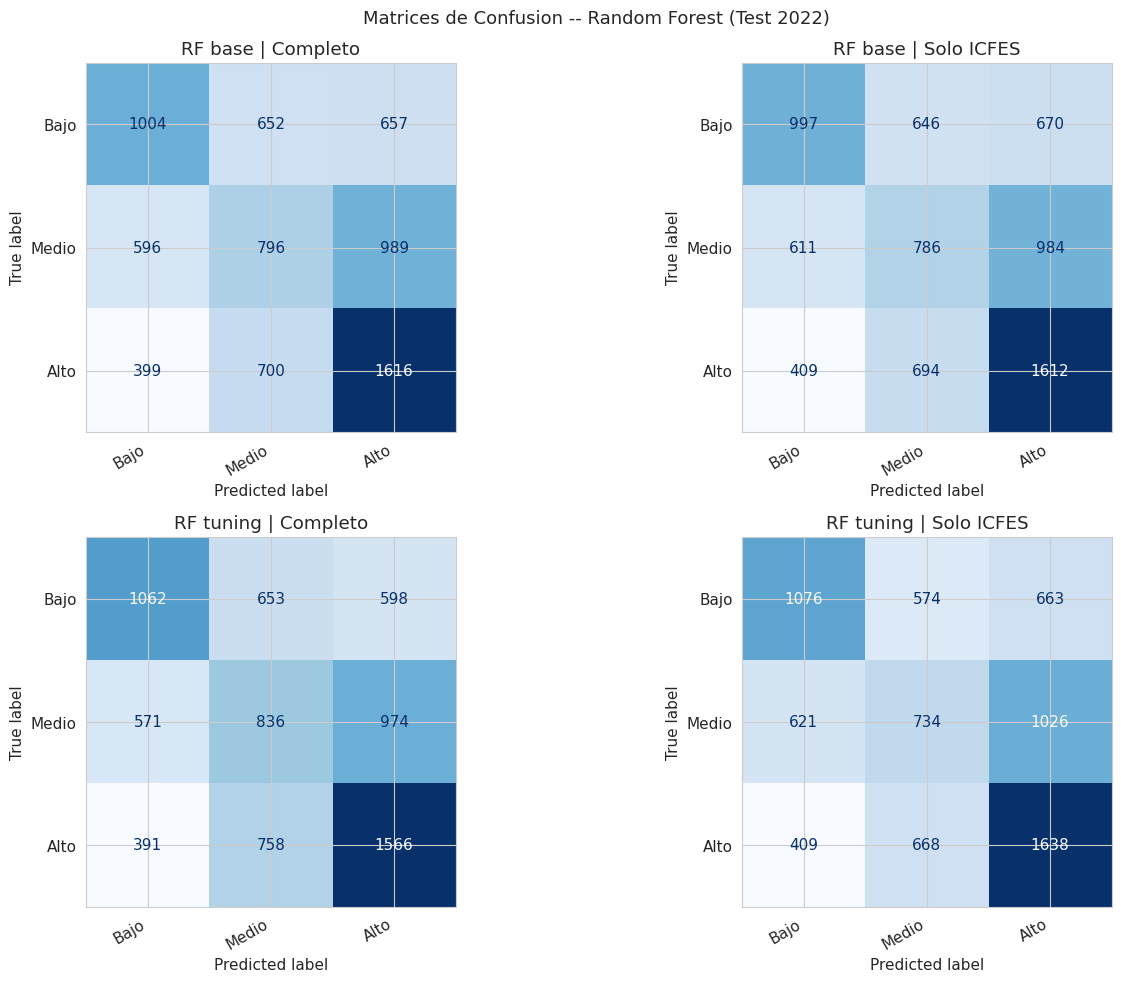

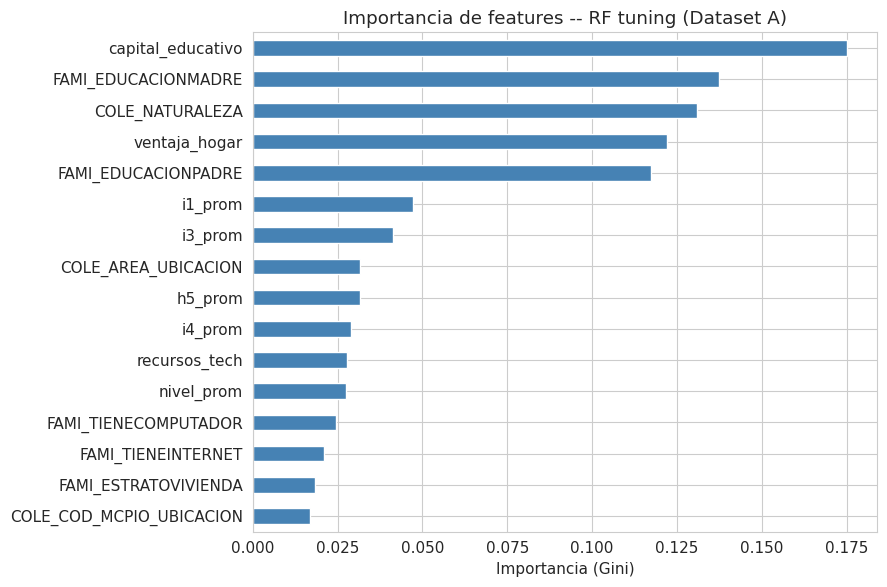


OK Random Forest completado.


In [48]:
# Celda 6.1 -- Random Forest Classifier
# El Random Forest construye multiples arboles de decision en paralelo,
# cada uno entrenado sobre una muestra aleatoria de los datos y
# un subconjunto aleatorio de features. La prediccion final es
# por votacion de todos los arboles — esto reduce el sobreajuste
# y estabiliza las predicciones frente a arboles individuales.

# Lista global de resultados — se puebla en 6.1, 6.2, 6.3, 7.1
resultados_todos = []

def registrar(nombre, ds_name, y_pred):
    resultados_todos.append({
        "Modelo"      : nombre,
        "Dataset"     : ds_name,
        "Accuracy"    : accuracy_score(y_test, y_pred),
        "F1 macro"    : f1_score(y_test, y_pred, average="macro"),
        "F1 weighted" : f1_score(y_test, y_pred, average="weighted"),
    })

LABELS = [CLASES_TARGET[i] for i in sorted(CLASES_TARGET.keys())]

rf_params = [
    ("RF base",
     dict(n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1)),
    ("RF tuning",
     dict(n_estimators=500, max_depth=20, min_samples_leaf=5,
          class_weight="balanced", random_state=42, n_jobs=-1)),
]

rf_preds = {}   # guarda predicciones para graficar
rf_models = {}  # guarda modelos entrenados

for cfg, params in rf_params:
    for ds_name, X_tr, X_te, feats in DATASETS:
        m = RandomForestClassifier(**params)
        m.fit(X_tr, y_train)
        y_pred = m.predict(X_te)
        rf_preds[(cfg, ds_name)]  = y_pred
        rf_models[(cfg, ds_name)] = (m, feats)
        registrar(cfg, ds_name, y_pred)
        acc = accuracy_score(y_test, y_pred)
        f1m = f1_score(y_test, y_pred, average="macro")
        f1w = f1_score(y_test, y_pred, average="weighted")
        print(f"\n=== {cfg} | {ds_name} ===")
        print(f"  Accuracy: {acc:.4f}  F1 macro: {f1m:.4f}  F1 weighted: {f1w:.4f}")
        print(classification_report(y_test, y_pred, target_names=LABELS))

# Matrices de confusion 2x2
cfgs  = [p[0] for p in rf_params]
dsets = [d[0] for d in DATASETS]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for r, cfg in enumerate(cfgs):
    for c, ds_name in enumerate(dsets):
        cm = confusion_matrix(y_test, rf_preds[(cfg, ds_name)])
        ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(
            ax=axes[r, c], cmap="Blues", colorbar=False)
        axes[r, c].set_title(f"{cfg} | {ds_name}")
        plt.setp(axes[r, c].get_xticklabels(), rotation=30, ha="right")
plt.suptitle("Matrices de Confusion -- Random Forest (Test 2022)", fontsize=13)
plt.tight_layout()
plt.show()

# Feature importance del mejor RF (tuned, Dataset A)
best_rf, best_feats = rf_models[("RF tuning", "Completo")]
imp_rf = pd.Series(best_rf.feature_importances_, index=best_feats).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 6))
imp_rf.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Importancia de features -- RF tuning (Dataset A)")
ax.set_xlabel("Importancia (Gini)")
plt.tight_layout()
plt.show()

rf_best = best_rf  # referencia global para seccion 9
print("\nOK Random Forest completado.")



=== XGBoost base | Completo ===
  Accuracy: 0.4646  F1 macro: 0.4608  F1 weighted: 0.4636
              precision    recall  f1-score   support

        Bajo       0.53      0.46      0.49      2313
       Medio       0.36      0.36      0.36      2381
        Alto       0.50      0.56      0.53      2715

    accuracy                           0.46      7409
   macro avg       0.46      0.46      0.46      7409
weighted avg       0.47      0.46      0.46      7409


=== XGBoost base | Solo ICFES ===
  Accuracy: 0.4605  F1 macro: 0.4572  F1 weighted: 0.4598
              precision    recall  f1-score   support

        Bajo       0.52      0.46      0.49      2313
       Medio       0.36      0.36      0.36      2381
        Alto       0.50      0.55      0.52      2715

    accuracy                           0.46      7409
   macro avg       0.46      0.46      0.46      7409
weighted avg       0.46      0.46      0.46      7409


=== XGBoost tuning | Completo ===
  Accuracy: 0.4555 

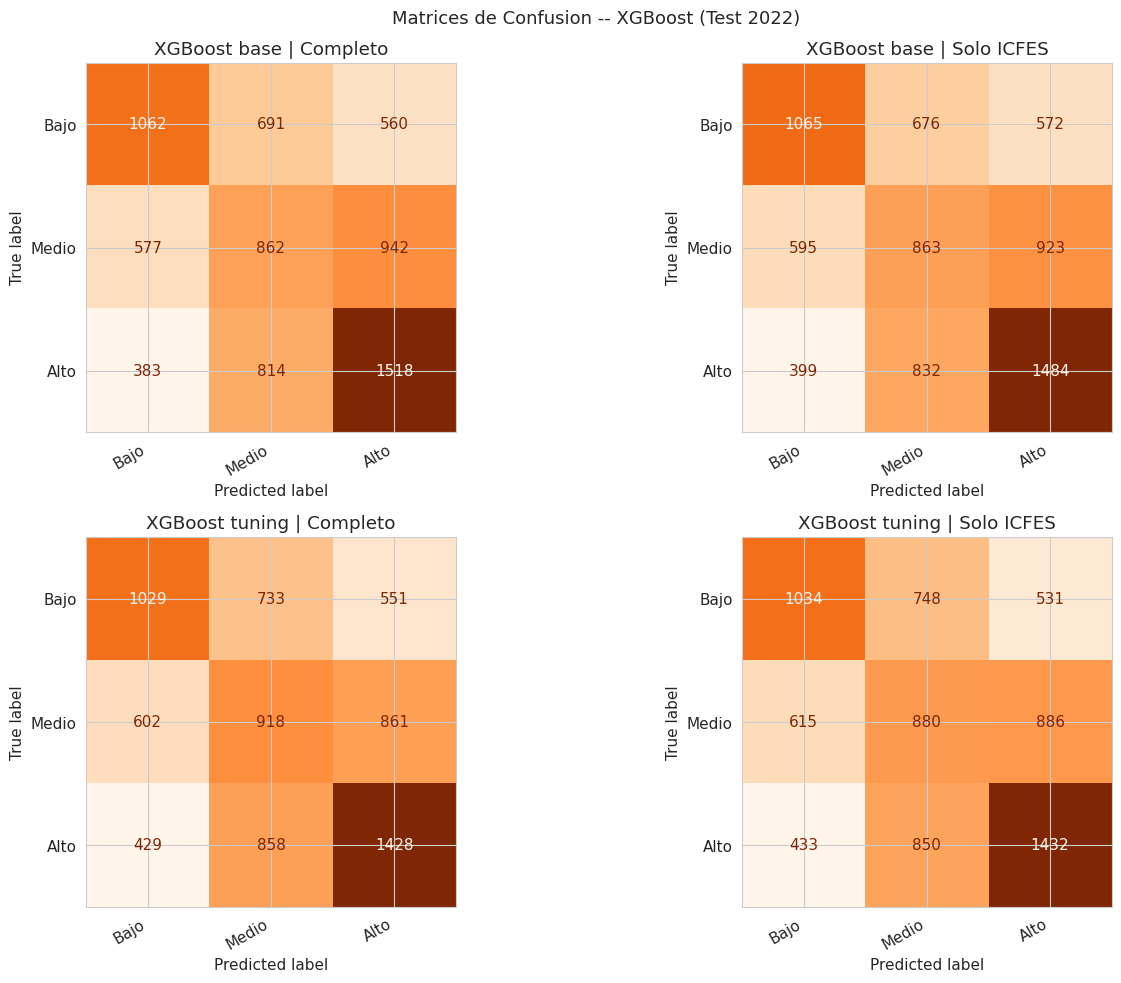


OK XGBoost completado.


In [49]:
# Celda 6.2 -- XGBoost Classifier
# XGBoost es un algoritmo de boosting: a diferencia del Random Forest
# que construye arboles en paralelo e independientes, XGBoost construye
# cada arbol para corregir los errores del arbol anterior. Aprende
# iterativamente de sus equivocaciones, lo que lo hace mas preciso
# en datos tabulares. El termino "gradient" viene de que minimiza
# la funcion de perdida mediante descenso por gradiente.

xgb_params = [
    ("XGBoost base",
     dict(n_estimators=200, learning_rate=0.1, max_depth=6,
          random_state=42, eval_metric="mlogloss", verbosity=0)),
    ("XGBoost tuning",
     dict(n_estimators=500, learning_rate=0.05, max_depth=8,
          subsample=0.8, colsample_bytree=0.8,
          random_state=42, eval_metric="mlogloss", verbosity=0)),
]

xgb_preds = {}

for cfg, params in xgb_params:
    for ds_name, X_tr, X_te, feats in DATASETS:
        m = XGBClassifier(**params)
        m.fit(X_tr, y_train)
        y_pred = m.predict(X_te)
        xgb_preds[(cfg, ds_name)] = y_pred
        registrar(cfg, ds_name, y_pred)
        acc = accuracy_score(y_test, y_pred)
        f1m = f1_score(y_test, y_pred, average="macro")
        f1w = f1_score(y_test, y_pred, average="weighted")
        print(f"\n=== {cfg} | {ds_name} ===")
        print(f"  Accuracy: {acc:.4f}  F1 macro: {f1m:.4f}  F1 weighted: {f1w:.4f}")
        print(classification_report(y_test, y_pred, target_names=LABELS))

cfgs  = [p[0] for p in xgb_params]
dsets = [d[0] for d in DATASETS]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for r, cfg in enumerate(cfgs):
    for c, ds_name in enumerate(dsets):
        cm = confusion_matrix(y_test, xgb_preds[(cfg, ds_name)])
        ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(
            ax=axes[r, c], cmap="Oranges", colorbar=False)
        axes[r, c].set_title(f"{cfg} | {ds_name}")
        plt.setp(axes[r, c].get_xticklabels(), rotation=30, ha="right")
plt.suptitle("Matrices de Confusion -- XGBoost (Test 2022)", fontsize=13)
plt.tight_layout()
plt.show()

print("\nOK XGBoost completado.")



=== LightGBM base | Completo ===
  Accuracy: 0.4659  F1 macro: 0.4607  F1 weighted: 0.4639
              precision    recall  f1-score   support

        Bajo       0.52      0.45      0.49      2313
       Medio       0.37      0.35      0.36      2381
        Alto       0.50      0.57      0.54      2715

    accuracy                           0.47      7409
   macro avg       0.46      0.46      0.46      7409
weighted avg       0.47      0.47      0.46      7409


=== LightGBM base | Solo ICFES ===
  Accuracy: 0.4617  F1 macro: 0.4562  F1 weighted: 0.4593
              precision    recall  f1-score   support

        Bajo       0.51      0.46      0.48      2313
       Medio       0.37      0.35      0.36      2381
        Alto       0.50      0.57      0.53      2715

    accuracy                           0.46      7409
   macro avg       0.46      0.46      0.46      7409
weighted avg       0.46      0.46      0.46      7409


=== LightGBM tuning | Completo ===
  Accuracy: 0.46

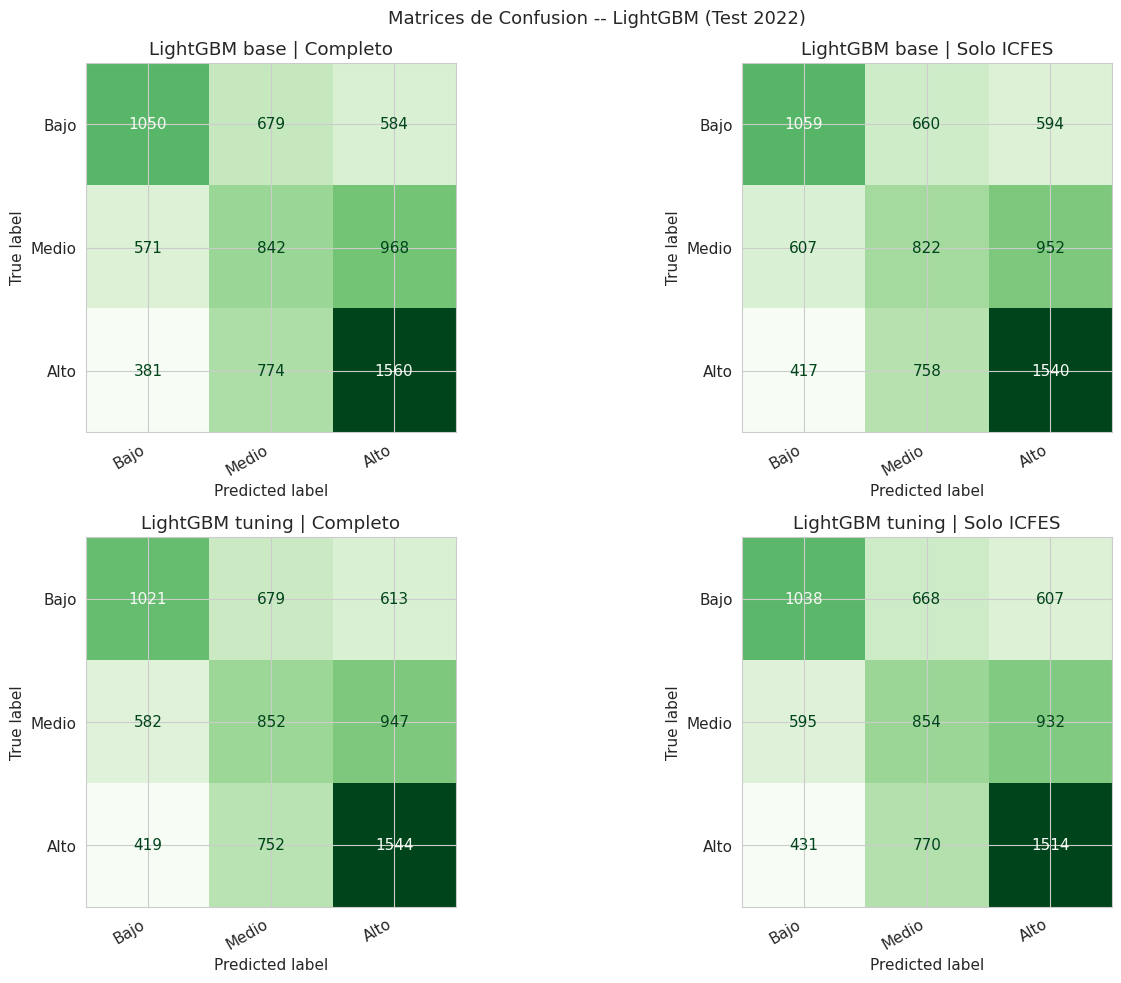


OK LightGBM completado.


In [50]:
# Celda 6.3 -- LightGBM Classifier
# LightGBM es similar a XGBoost pero mas rapido: usa crecimiento de
# arbol por hojas (leaf-wise) en lugar de por niveles (level-wise).
# El crecimiento leaf-wise reduce el error mas agresivamente en cada
# paso, lo que da mejores resultados con menos iteraciones. En datasets
# grandes es significativamente mas rapido que XGBoost con resultados
# similares o mejores.

lgbm_params = [
    ("LightGBM base",
     dict(n_estimators=200, learning_rate=0.1, num_leaves=31,
          class_weight="balanced", random_state=42, verbosity=-1)),
    ("LightGBM tuning",
     dict(n_estimators=500, learning_rate=0.05, num_leaves=63,
          min_child_samples=20, subsample=0.8, subsample_freq=1,
          class_weight="balanced", random_state=42, verbosity=-1)),
]

lgbm_preds = {}

for cfg, params in lgbm_params:
    for ds_name, X_tr, X_te, feats in DATASETS:
        m = LGBMClassifier(**params)
        m.fit(X_tr, y_train)
        y_pred = m.predict(X_te)
        lgbm_preds[(cfg, ds_name)] = y_pred
        registrar(cfg, ds_name, y_pred)
        acc = accuracy_score(y_test, y_pred)
        f1m = f1_score(y_test, y_pred, average="macro")
        f1w = f1_score(y_test, y_pred, average="weighted")
        print(f"\n=== {cfg} | {ds_name} ===")
        print(f"  Accuracy: {acc:.4f}  F1 macro: {f1m:.4f}  F1 weighted: {f1w:.4f}")
        print(classification_report(y_test, y_pred, target_names=LABELS))

cfgs  = [p[0] for p in lgbm_params]
dsets = [d[0] for d in DATASETS]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for r, cfg in enumerate(cfgs):
    for c, ds_name in enumerate(dsets):
        cm = confusion_matrix(y_test, lgbm_preds[(cfg, ds_name)])
        ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(
            ax=axes[r, c], cmap="Greens", colorbar=False)
        axes[r, c].set_title(f"{cfg} | {ds_name}")
        plt.setp(axes[r, c].get_xticklabels(), rotation=30, ha="right")
plt.suptitle("Matrices de Confusion -- LightGBM (Test 2022)", fontsize=13)
plt.tight_layout()
plt.show()

print("\nOK LightGBM completado.")


=== TABLA COMPARATIVA EXTENDIDA (con Acc. Adyacente) ===


,Modelo,Dataset,Accuracy,F1 macro,F1 weighted,Acc. Adyacente
0,RF tuning,Completo,0.4675,0.4620,0.4651,0.8665
1,XGBoost base,Completo,0.4646,0.4608,0.4636,0.8727
2,LightGBM base,Completo,0.4659,0.4607,0.4639,0.8698
3,XGBoost base,Solo ICFES,0.4605,0.4572,0.4598,0.8689
4,LightGBM base,Solo ICFES,0.4617,0.4562,0.4593,0.8635
5,LightGBM tuning,Completo,0.4612,0.4557,0.4589,0.8607
6,RF tuning,Solo ICFES,0.4654,0.4554,0.4590,0.8553
7,LightGBM tuning,Solo ICFES,0.4597,0.4549,0.4579,0.8599
8,XGBoost tuning,Completo,0.4555,0.4534,0.4560,0.8677
9,RF base,Completo,0.4611,0.4526,0.4565,0.8575


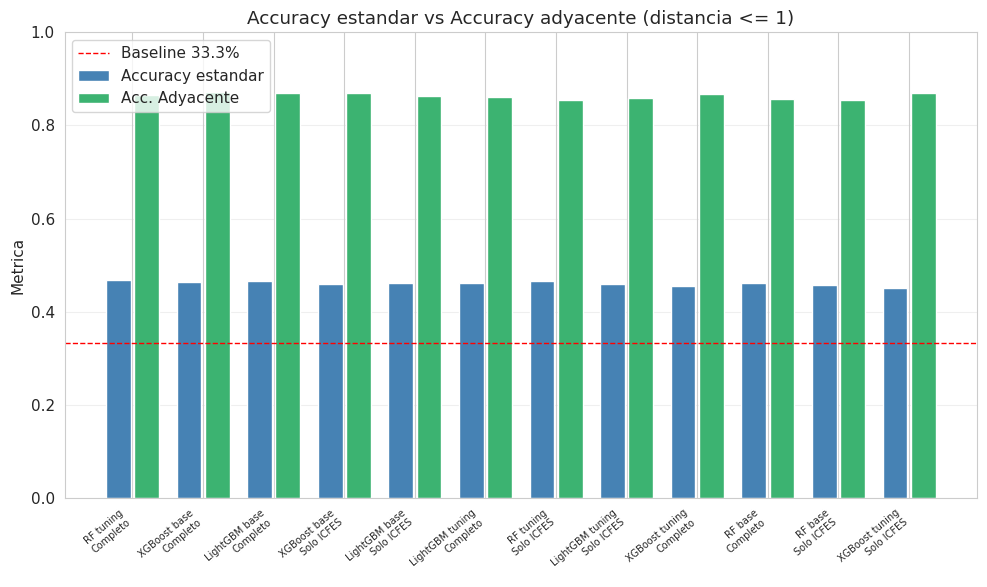


--- Analisis de errores: RF tuning | Completo ---
Total estudiantes en test (2022): 7,409
  Exactamente correctos     : 3,464  (46.8%)
  Error de 1 nivel (adj.)   : 2,956  (39.9%)
  Error de 2 niveles (grave): 989  (13.3%)

Accuracy estandar  : 0.4675
Accuracy adyacente : 0.8665  (+39.9 pp al incluir adyacentes)


In [51]:
# Celda 6.5 -- Accuracy por adyacencia (metrica ordinal)
#
# PROBLEMA DEL ACCURACY ESTANDAR EN CLASES ORDINALES:
# El accuracy estandar penaliza igual confundir Bajo->Medio (error leve)
# que confundir Bajo->Alto (error grave). Para clases ordinales esto es
# incorrecto desde el punto de vista pedagogico y de politica publica.
#
# SOLUCCION — ACCURACY POR ADYACENCIA:
# Cuenta como acierto cualquier prediccion que este a distancia <= 1
# del valor real. Con 3 clases (0=Bajo, 1=Medio, 2=Alto):
#   - Predijo Bajo  cuando era Medio  → acierto adyacente (off by 1)
#   - Predijo Alto  cuando era Medio  → acierto adyacente (off by 1)
#   - Predijo Bajo  cuando era Alto   → error grave (off by 2)
# Es mas honesta para reportar al Ministerio: refleja cuan cerca
# estuvo el modelo de la clase correcta, no solo si acerto exacto.

def accuracy_adyacente(y_true, y_pred):
    return (np.abs(np.array(y_true) - np.array(y_pred)) <= 1).mean()

# Recopilar todas las predicciones de los 3 modelos x 2 datasets
all_preds_6 = {}
all_preds_6.update(rf_preds)
all_preds_6.update(xgb_preds)
all_preds_6.update(lgbm_preds)

# Construir tabla extendida (solo modelos 6.1-6.3, no MLP)
rows_ext = []
for entrada in resultados_todos:
    key = (entrada["Modelo"], entrada["Dataset"])
    if key not in all_preds_6:
        continue   # saltar MLP si ya esta en resultados_todos
    y_pred = all_preds_6[key]
    rows_ext.append({
        "Modelo"        : entrada["Modelo"],
        "Dataset"       : entrada["Dataset"],
        "Accuracy"      : entrada["Accuracy"],
        "F1 macro"      : entrada["F1 macro"],
        "F1 weighted"   : entrada["F1 weighted"],
        "Acc. Adyacente": accuracy_adyacente(y_test, y_pred),
    })

df_ext = (pd.DataFrame(rows_ext)
          .sort_values("F1 macro", ascending=False)
          .reset_index(drop=True))

print("=== TABLA COMPARATIVA EXTENDIDA (con Acc. Adyacente) ===")
display(df_ext.style
         .format({"Accuracy":"{:.4f}","F1 macro":"{:.4f}",
                  "F1 weighted":"{:.4f}","Acc. Adyacente":"{:.4f}"})
         .highlight_max(subset=["Accuracy","F1 macro","Acc. Adyacente"],
                        color="lightgreen", axis=0)
         .highlight_min(subset=["Accuracy","F1 macro","Acc. Adyacente"],
                        color="#ffcccc", axis=0))

# Grafico comparativo Accuracy vs Acc. Adyacente
fig, ax = plt.subplots(figsize=(10, 6))
labels_graf = [f"{r['Modelo']}\n{r['Dataset']}" for _, r in df_ext.iterrows()]
x = range(len(df_ext))
ax.bar([i - 0.2 for i in x], df_ext["Accuracy"],       0.35,
       label="Accuracy estandar", color="steelblue",    edgecolor="white")
ax.bar([i + 0.2 for i in x], df_ext["Acc. Adyacente"], 0.35,
       label="Acc. Adyacente",    color="mediumseagreen",edgecolor="white")
ax.set_xticks(list(x))
ax.set_xticklabels(labels_graf, fontsize=7, rotation=40, ha="right")
ax.set_ylim(0, 1)
ax.axhline(1/3, color="red", linestyle="--", linewidth=1, label="Baseline 33.3%")
ax.set_title("Accuracy estandar vs Accuracy adyacente (distancia <= 1)")
ax.set_ylabel("Metrica")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Analisis detallado del mejor modelo
mejor_row   = df_ext.iloc[0]
mejor_model = mejor_row["Modelo"]
mejor_ds    = mejor_row["Dataset"]
best_pred   = all_preds_6[(mejor_model, mejor_ds)]

y_true_arr  = np.array(y_test)
y_pred_arr  = np.array(best_pred)
diferencias = np.abs(y_true_arr - y_pred_arr)

exactos    = int((diferencias == 0).sum())
adyacentes = int((diferencias == 1).sum())
graves     = int((diferencias == 2).sum())
total      = len(y_test)

print(f"\n--- Analisis de errores: {mejor_model} | {mejor_ds} ---")
print(f"Total estudiantes en test (2022): {total:,}")
print(f"  Exactamente correctos     : {exactos:,}  ({exactos/total*100:.1f}%)")
print(f"  Error de 1 nivel (adj.)   : {adyacentes:,}  ({adyacentes/total*100:.1f}%)")
print(f"  Error de 2 niveles (grave): {graves:,}  ({graves/total*100:.1f}%)")
print(f"\nAccuracy estandar  : {exactos/total:.4f}")
print(f"Accuracy adyacente : {(exactos+adyacentes)/total:.4f}  "
      f"(+{(adyacentes)/total*100:.1f} pp al incluir adyacentes)")


P10 PUNT_GLOBAL: 207.0 puntos

Distribucion riesgo_critico:
  Resto (sin riesgo): 23,541  (89.9%)
  Muy bajo  (riesgo): 2,642  (10.1%)

Train: 1,922 en riesgo  (10.2%)
Test : 720 en riesgo  (9.7%)

METRICAS CLASIFICADOR BINARIO (clase Muy bajo = positivo)

=== RF binario ===
  Precision (Muy bajo): 0.2031  — de los pred. como riesgo, cuantos realmente lo eran
  Recall    (Muy bajo): 0.4500  — de los que realmente eran riesgo, cuantos detecto
  F1        (Muy bajo): 0.2799
  AUC-ROC             : 0.7043

  Reporte completo:
              precision    recall  f1-score   support

       Resto       0.93      0.81      0.87      6689
    Muy bajo       0.20      0.45      0.28       720

    accuracy                           0.78      7409
   macro avg       0.57      0.63      0.57      7409
weighted avg       0.86      0.78      0.81      7409


=== LightGBM binario ===
  Precision (Muy bajo): 0.2041  — de los pred. como riesgo, cuantos realmente lo eran
  Recall    (Muy bajo): 0.5000  

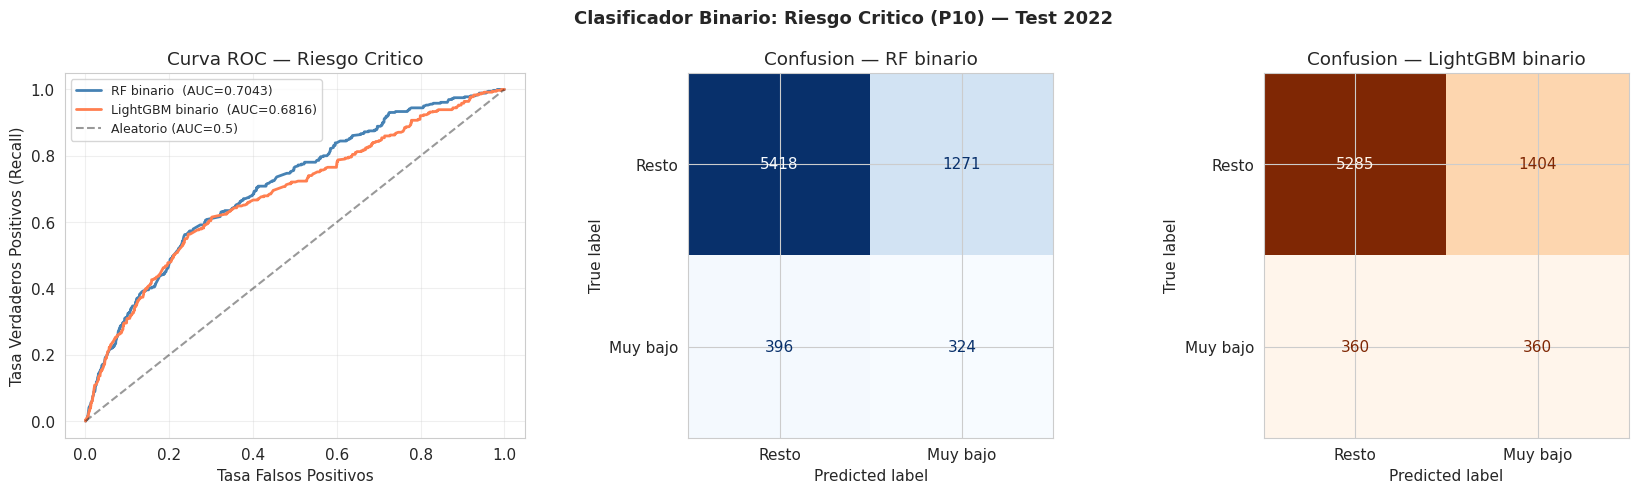

IMPACTO PRACTICO — LightGBM binario
De 7,409 estudiantes evaluados (Test 2022):
  Identificados correctamente en riesgo : 360  (4.9%)
  Falsa alarma (no eran riesgo)         : 1,404  (18.9%)
  En riesgo no detectados (perdidos)    : 360  (4.9%)
  Correctamente fuera de riesgo         : 5,285

Precision: de cada 10 alertas, ~2 son casos reales
Recall   : detecta ~50% de los estudiantes en riesgo


In [52]:
# Celda 6.6 -- Clasificador binario: riesgo critico (muy bajo, P10)
#
# POR QUE UN CLASIFICADOR BINARIO INDEPENDIENTE:
# En lugar de anadir una cuarta clase al modelo multiclase
# (lo que difuminaria las fronteras y empeoraría todas las clases),
# entrenamos un clasificador binario independiente cuyo unico
# objetivo es identificar estudiantes en riesgo critico.
# "Muy bajo" = estudiantes en el percentil 10 inferior de PUNT_GLOBAL.
# Este modelo es el mas util para el Ministerio: genera una lista
# confiable de estudiantes que necesitan intervencion prioritaria.
# Usar class_weight="balanced" es obligatorio porque la clase
# minoritaria (~10%) es precisamente la que importa detectar.

# ── 1. Crear target binario (P10 de PUNT_GLOBAL) ───────────────────
P10 = df_final["PUNT_GLOBAL"].quantile(0.10)
df_final["riesgo_critico"] = (df_final["PUNT_GLOBAL"] <= P10).astype(int)

print(f"P10 PUNT_GLOBAL: {P10:.1f} puntos")
print("\nDistribucion riesgo_critico:")
rc_counts = df_final["riesgo_critico"].value_counts().sort_index()
for v, n in rc_counts.items():
    etiq = "Muy bajo  (riesgo)" if v == 1 else "Resto (sin riesgo)"
    print(f"  {etiq}: {n:,}  ({n/len(df_final)*100:.1f}%)")

# ── 2. Split train/test (mismo que Dataset A) ────────────────────────
y_bin_train = df_final.loc[mask_train, "riesgo_critico"].values
y_bin_test  = df_final.loc[mask_test,  "riesgo_critico"].values

print(f"\nTrain: {(y_bin_train==1).sum():,} en riesgo  ({(y_bin_train==1).mean()*100:.1f}%)")
print(f"Test : {(y_bin_test==1).sum():,} en riesgo  ({(y_bin_test==1).mean()*100:.1f}%)")

# ── 3. Entrenar dos modelos con class_weight=balanced ─────────────────
# Usamos RF (mejor en tabla 6.4 en la mayoria de casos) y LightGBM como segundo.
bin_modelos = [
    ("RF binario",
     RandomForestClassifier(n_estimators=500, max_depth=20, min_samples_leaf=3,
                             class_weight="balanced", random_state=42, n_jobs=-1)),
    ("LightGBM binario",
     LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=63,
                    min_child_samples=10, class_weight="balanced",
                    random_state=42, verbosity=-1)),
]

bin_resultados = {}  # nombre -> (y_pred, y_prob)

for nombre, modelo in bin_modelos:
    modelo.fit(X_train_A, y_bin_train)
    y_pred_b = modelo.predict(X_test_A)
    y_prob_b = modelo.predict_proba(X_test_A)[:, 1]
    bin_resultados[nombre] = (y_pred_b, y_prob_b)

# ── 4. Metricas enfocadas en clase minoritaria ─────────────────────────
print("\n" + "=" * 60)
print("METRICAS CLASIFICADOR BINARIO (clase Muy bajo = positivo)")
print("=" * 60)

for nombre, (y_pred_b, y_prob_b) in bin_resultados.items():
    prec_mb = precision_score(y_bin_test, y_pred_b, pos_label=1, zero_division=0)
    rec_mb  = recall_score(y_bin_test,    y_pred_b, pos_label=1, zero_division=0)
    f1_mb   = f1_score(y_bin_test,        y_pred_b, pos_label=1, zero_division=0)
    auc     = roc_auc_score(y_bin_test, y_prob_b)
    print(f"\n=== {nombre} ===")
    print(f"  Precision (Muy bajo): {prec_mb:.4f}  "
          "— de los pred. como riesgo, cuantos realmente lo eran")
    print(f"  Recall    (Muy bajo): {rec_mb:.4f}  "
          "— de los que realmente eran riesgo, cuantos detecto")
    print(f"  F1        (Muy bajo): {f1_mb:.4f}")
    print(f"  AUC-ROC             : {auc:.4f}")
    print("\n  Reporte completo:")
    print(classification_report(y_bin_test, y_pred_b,
          target_names=["Resto", "Muy bajo"]))

# ── 5. Curva ROC + matrices de confusion ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Curva ROC (eje izquierdo)
colores_bin = ["steelblue", "coral"]
for (nombre, (y_pred_b, y_prob_b)), color in zip(bin_resultados.items(), colores_bin):
    fpr, tpr, _ = roc_curve(y_bin_test, y_prob_b)
    auc_val = roc_auc_score(y_bin_test, y_prob_b)
    axes[0].plot(fpr, tpr, color=color, linewidth=2,
                 label=f"{nombre}  (AUC={auc_val:.4f})")
axes[0].plot([0,1],[0,1],"k--", alpha=0.4, label="Aleatorio (AUC=0.5)")
axes[0].set_xlabel("Tasa Falsos Positivos")
axes[0].set_ylabel("Tasa Verdaderos Positivos (Recall)")
axes[0].set_title("Curva ROC — Riesgo Critico")
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Matriz de confusion por modelo
for ax, (nombre, (y_pred_b, _)), color in zip(axes[1:], bin_resultados.items(), colores_bin):
    cm_b = confusion_matrix(y_bin_test, y_pred_b)
    ConfusionMatrixDisplay(cm_b, display_labels=["Resto", "Muy bajo"]).plot(
        ax=ax, cmap="Blues" if color=="steelblue" else "Oranges", colorbar=False)
    ax.set_title(f"Confusion — {nombre}")

plt.suptitle("Clasificador Binario: Riesgo Critico (P10) — Test 2022",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 6. Impacto practico para el Ministerio ──────────────────────────
# Usar el modelo con mejor F1 en clase "Muy bajo"
mejor_bin = max(bin_resultados.items(),
                key=lambda x: f1_score(y_bin_test, x[1][0], pos_label=1, zero_division=0))
nombre_mejor_bin, (y_pred_mejor_bin, _) = mejor_bin

cm_best_b = confusion_matrix(y_bin_test, y_pred_mejor_bin)
tn, fp, fn, tp = cm_best_b.ravel()
total_test_b = len(y_bin_test)

print("=" * 60)
print(f"IMPACTO PRACTICO — {nombre_mejor_bin}")
print("=" * 60)
print(f"De {total_test_b:,} estudiantes evaluados (Test 2022):")
print(f"  Identificados correctamente en riesgo : {tp:,}"
      f"  ({tp/total_test_b*100:.1f}%)")
print(f"  Falsa alarma (no eran riesgo)         : {fp:,}"
      f"  ({fp/total_test_b*100:.1f}%)")
print(f"  En riesgo no detectados (perdidos)    : {fn:,}"
      f"  ({fn/total_test_b*100:.1f}%)")
print(f"  Correctamente fuera de riesgo         : {tn:,}")
print(f"\nPrecision: de cada 10 alertas, ~{precision_score(y_bin_test, y_pred_mejor_bin, pos_label=1, zero_division=0)*10:.0f} son casos reales")
print(f"Recall   : detecta ~{recall_score(y_bin_test, y_pred_mejor_bin, pos_label=1, zero_division=0)*100:.0f}% de los estudiantes en riesgo")



=== MLP | Completo ===
  Epocas: 21  Perdida final: 10.6095
  Accuracy: 0.4109  F1 macro: 0.3261  F1 weighted: 0.3316
              precision    recall  f1-score   support

        Bajo       0.38      0.72      0.49      2313
       Medio       0.00      0.00      0.00      2381
        Alto       0.46      0.51      0.48      2715

    accuracy                           0.41      7409
   macro avg       0.28      0.41      0.33      7409
weighted avg       0.29      0.41      0.33      7409


=== MLP | Solo ICFES ===
  Epocas: 62  Perdida final: 2.9807
  Accuracy: 0.4478  F1 macro: 0.4015  F1 weighted: 0.4076
              precision    recall  f1-score   support

        Bajo       0.43      0.55      0.48      2313
       Medio       0.38      0.11      0.17      2381
        Alto       0.47      0.66      0.55      2715

    accuracy                           0.45      7409
   macro avg       0.43      0.44      0.40      7409
weighted avg       0.43      0.45      0.41      7409


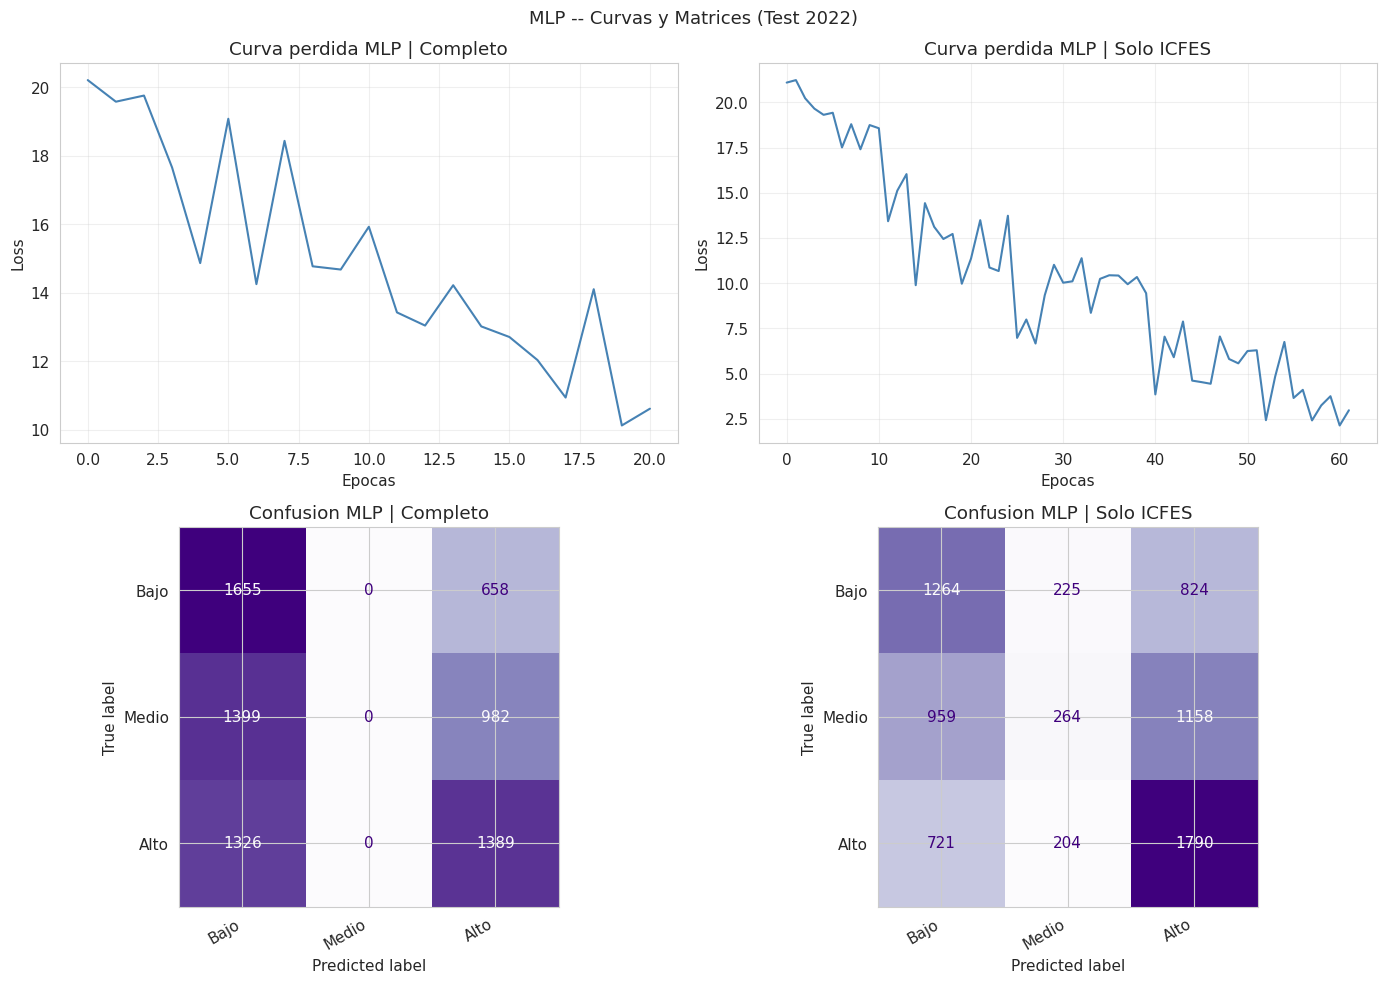


=== TABLA COMPARATIVA FINAL (todos los modelos) ===


,Modelo,Dataset,Accuracy,F1 macro,F1 weighted
0,RF tuning,Completo,0.4675,0.4620,0.4651
1,XGBoost base,Completo,0.4646,0.4608,0.4636
2,LightGBM base,Completo,0.4659,0.4607,0.4639
3,XGBoost base,Solo ICFES,0.4605,0.4572,0.4598
4,LightGBM base,Solo ICFES,0.4617,0.4562,0.4593
5,LightGBM tuning,Completo,0.4612,0.4557,0.4589
6,RF tuning,Solo ICFES,0.4654,0.4554,0.4590
7,LightGBM tuning,Solo ICFES,0.4597,0.4549,0.4579
8,XGBoost tuning,Completo,0.4555,0.4534,0.4560
9,RF base,Completo,0.4611,0.4526,0.4565



Mejor modelo global: RF tuning | Completo
  Accuracy   : 0.4675
  F1 macro   : 0.4620
  F1 weighted: 0.4651

OK MLP completado. Tabla final disponible en df_res_final.


In [53]:
# Celda 7.1 -- MLP Classifier (Red Neuronal Multicapa)
# Una red neuronal aprende representaciones intermedias de los datos:
# en lugar de usar las features directamente, aprende combinaciones
# NO lineales de ellas en capas ocultas. Cada neurona aplica una
# funcion de activacion (ReLU) sobre una combinacion de entradas,
# lo que le permite capturar interacciones complejas que los arboles
# no pueden representar con una sola particion binaria.
# Para datos tabulares como los nuestros, una red pequena de 2-3
# capas es suficiente y puede capturar interacciones que los
# arboles no ven de forma nativa.

mlp_preds = {}

mlp_params = dict(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42,
)

for ds_name, X_tr, X_te, feats in DATASETS:
    m = MLPClassifier(**mlp_params)
    m.fit(X_tr, y_train)
    y_pred = m.predict(X_te)
    mlp_preds[ds_name] = (m, y_pred)
    registrar("MLP", ds_name, y_pred)
    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average="macro")
    f1w = f1_score(y_test, y_pred, average="weighted")
    print(f"\n=== MLP | {ds_name} ===")
    print(f"  Epocas: {m.n_iter_}  Perdida final: {m.loss_:.4f}")
    print(f"  Accuracy: {acc:.4f}  F1 macro: {f1m:.4f}  F1 weighted: {f1w:.4f}")
    print(classification_report(y_test, y_pred, target_names=LABELS))

# Curvas de perdida y matrices de confusion
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for col, (ds_name, X_tr, X_te, _) in enumerate(DATASETS):
    m_mlp, y_pred = mlp_preds[ds_name]
    axes[0, col].plot(m_mlp.loss_curve_, color="steelblue")
    axes[0, col].set_title(f"Curva perdida MLP | {ds_name}")
    axes[0, col].set_xlabel("Epocas"); axes[0, col].set_ylabel("Loss")
    axes[0, col].grid(alpha=0.3)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(
        ax=axes[1, col], cmap="Purples", colorbar=False)
    axes[1, col].set_title(f"Confusion MLP | {ds_name}")
    plt.setp(axes[1, col].get_xticklabels(), rotation=30, ha="right")
plt.suptitle("MLP -- Curvas y Matrices (Test 2022)", fontsize=13)
plt.tight_layout()
plt.show()

# Tabla comparativa final actualizada (12 modelos arboles + 2 MLP = 14 filas)
df_res_final = (pd.DataFrame(resultados_todos)
                .sort_values("F1 macro", ascending=False)
                .reset_index(drop=True))
print("\n=== TABLA COMPARATIVA FINAL (todos los modelos) ===")
display(df_res_final.style
         .format({"Accuracy":"{:.4f}","F1 macro":"{:.4f}","F1 weighted":"{:.4f}"})
         .highlight_max(subset=["Accuracy","F1 macro","F1 weighted"],
                        color="lightgreen", axis=0))

mejor_final = df_res_final.iloc[0]
print(f"\nMejor modelo global: {mejor_final['Modelo']} | {mejor_final['Dataset']}")
print(f"  Accuracy   : {mejor_final['Accuracy']:.4f}")
print(f"  F1 macro   : {mejor_final['F1 macro']:.4f}")
print(f"  F1 weighted: {mejor_final['F1 weighted']:.4f}")
print("\nOK MLP completado. Tabla final disponible en df_res_final.")
